# Kenbec inversion data with the quintic B-spline convolution-free matrix

This notebook applies a convolution-free quintic B-spline method to the Kenbec LM + HM data. The key idea is to move the waveform and receiver-gate operations into fixed matrices, so each forward prediction becomes

$$d_\text{pred} = M_\text{system}\,B_\text{step}(t_i).$$

Following the nomenclature of Christensen, Christiansen, Auken & Foged (2026), $B_\text{step}(t_i)$ is the **step response** (the response to a step turn-off of the transmitter current), and $M_\text{system}$ applies the **system response**: the transmitter waveform, the finite receiver-gate averaging, and (where present) the receiver/amplifier low-pass filters. In Christensen's formulation the waveform enters as a convolution of the step response with the **second derivative of the piecewise-linear transmitter waveform**; here that convolution, the gate averaging, and the quintic B-spline interpolation are all baked once into $M_\text{system}$, so the inversion no longer repeats the waveform convolution for every trial model.

This notebook keeps the Kenbec controls from the inversion notebook: LM and HM are prepared together, the sounding can be a stacked mean or one station, and the loop can be treated as either an equal-area circular offset loop or a square offset loop.

## Nomenclature (Christensen et al. 2026)

The physics in `pytem` and the wording in this notebook follow the conventions of Christensen, Christiansen, Auken & Foged (2026), with the symbol/name correspondences below. `pytem` computes the layered response with an upward reflection-coefficient recursion and a digital-linear-filter (DLF) Hankel transform plus a Fourier sine/cosine time transform; Christensen instead use a Schelkunoff-potential recursion with a Fast Hankel Transform and a Gaver-Stehfest inverse Laplace transform. The two schemes are different but validated against the same analytic half-space expressions, so the terms below refer to the same physical quantities.

| Christensen (2026) | This notebook / `pytem` | Meaning |
|---|---|---|
| step response | `B_step`, "step response" | response to an ideal step turn-off of the transmitter current |
| system response | `M_system`, `M_gate` | waveform convolution + finite receiver-gate averaging + Rx/amplifier filters |
| waveform convolution | quintic B-spline waveform matrix | convolution of the step response with the second derivative of the piecewise-linear waveform |
| $\gamma_0$ (reflection coefficient) | `r_TE` (TE surface reflection coefficient) | surface TE reflection coefficient of the layered earth |
| $u_n$ (layer wavenumber) | `Gamma` | vertical wavenumber $\sqrt{\lambda^2 + i\omega\mu_0\sigma_n}$ in layer $n$ |
| $\psi_{n+1}$ (interface term) | `psi` | $(u_n - u_{n+1})/(u_n + u_{n+1})$ interface reflection term |
| $\lambda$ (horizontal wavenumber) | `lam` | Hankel-transform integration variable |
| central-loop kernel factor $J_1(\lambda a)/(\tfrac{1}{2}\lambda a)$ | circular-loop kernel in `fwd_circle_*` | vertical field of a circular transmitter loop |

**System response** here means the same thing as in Christensen: transmitter waveform convolution, finite receiver-gate integration, and (when configured) the receiver-bandwidth and amplifier Butterworth low-pass filters (`pytem.system_filter`). This notebook uses the waveform + gate parts of the system response; no explicit receiver/amplifier filter is configured.


In [1]:
import sys, importlib, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# Locate the pyTEM repo root (the folder containing the `pytem` package) by
# searching upward from the working directory, so no absolute path is needed.
ROOT = None
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        ROOT = str(_root)
        break
if ROOT and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from pytem import fwd_circle_offset, fwd_square_offset, read_xyz, Survey
from pytem.waveform import setup_waveform

plt.rcParams['figure.dpi'] = 115


In [2]:
import sys, importlib
from pathlib import Path

# 1. Snapshot modules before loading pyTEM
before = set(sys.modules.keys())

# 2. Locate the pyTEM repo root and add it to sys.path (portable; no absolute path)
ROOT = None
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        ROOT = str(_root)
        break
if ROOT and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pytem

# 3. See what pyTEM actually loaded into memory
after = set(sys.modules.keys())
newly_loaded = {m.split('.')[0] for m in (after - before) if not m.startswith('_')}

# Filter out Python standard library & local pyTEM package
stdlib = getattr(sys, "stdlib_module_names", set())
external_packages = [pkg for pkg in newly_loaded if pkg not in stdlib and pkg != "pytem"]

# 4. Print results
print("--- Packages actively used by pyTEM ---")
for pkg in sorted(external_packages):
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "Installed")
        print(f"✅ {pkg:<14}: {ver}")
    except Exception:
        print(f"✅ {pkg:<14}: Installed")

--- Packages actively used by pyTEM ---


## 1. Read the Kenbec station data

The reader returns the TEMImage-Beta station table, LM/HM gate times, LM/HM transmitter waveforms, and the survey geometry. The data are still in the same form used by the Kenbec inversion notebook; this notebook only changes how the waveform and gate response are computed.

In [3]:
XYZ = r"C:\Users\pamcl\Downloads\Kenbec\kenbec_project_StationData.xyz"
tem = read_xyz(XYZ)

print(f"Stations : {len(tem.data)}")
for moment in ('LM', 'HM'):
    centers = tem.gate_times[moment]['center']
    print(f"  {moment}: {len(centers)} gates  [{centers[0]:.2e} ... {centers[-1]:.2e}] s")
print(f"Loop : {tem.meta.get('LoopX')} x {tem.meta.get('LoopY')} m, "
      f"{tem.meta.get('LoopTurns')} turns  |  Rx x = {tem.meta.get('RXcoil_X_Position')} m")


Stations : 38
  LM: 6 gates  [1.09e-05 ... 2.94e-05] s
  HM: 22 gates  [2.24e-05 ... 2.37e-03] s
Loop : None x None m, 2 turns  |  Rx x = None m


### Quick-look: SNR, station map, and transects

Folded in from the earlier exploratory Kenbec notebook, now built on `pytem.Survey` instead of ad-hoc plotting code. LM and HM are always shown as separate curves -- each moment has its own transmitter waveform, so a combined decay curve would silently mix two different system responses.


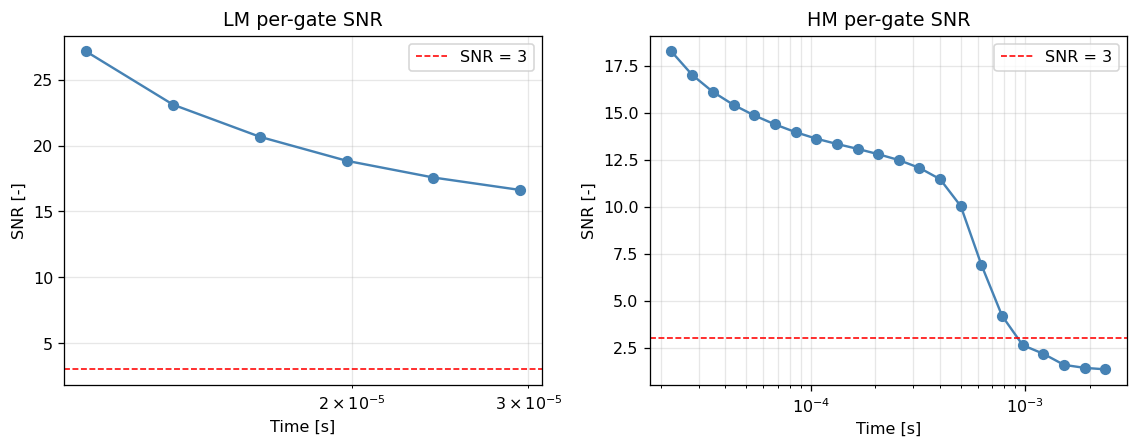

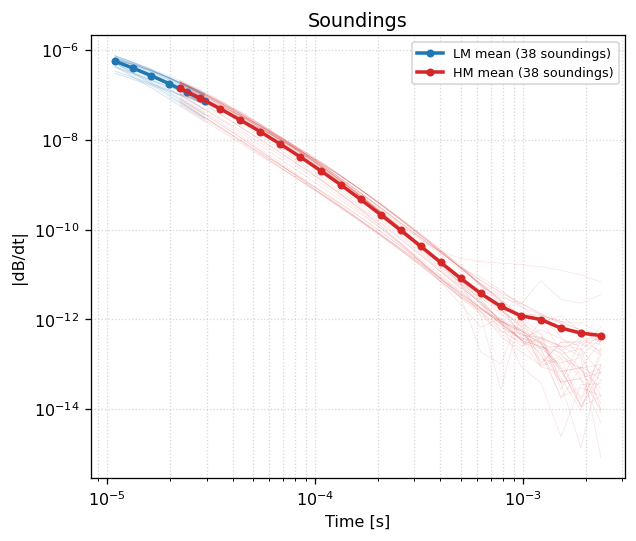

c:\WPy64-31180\python-3.11.8.amd64\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


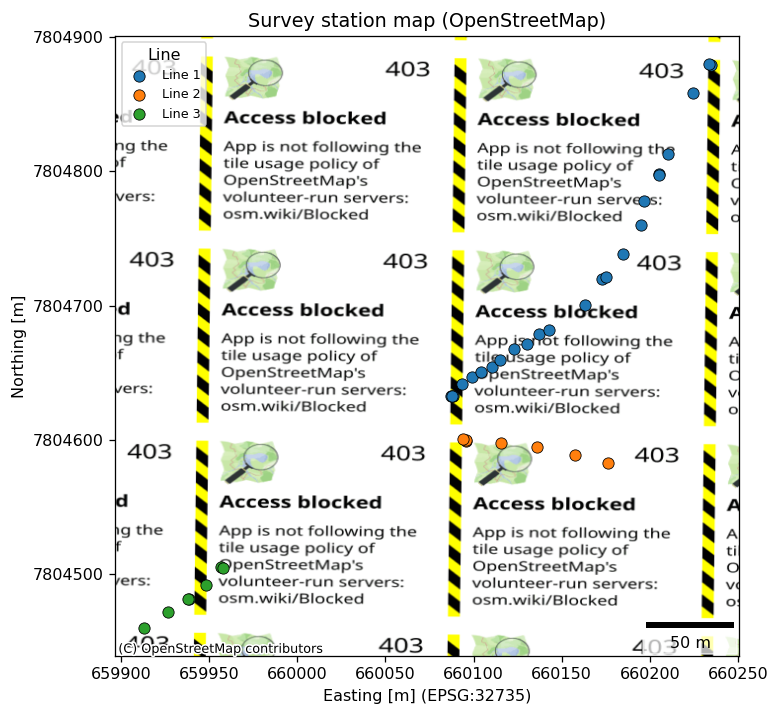

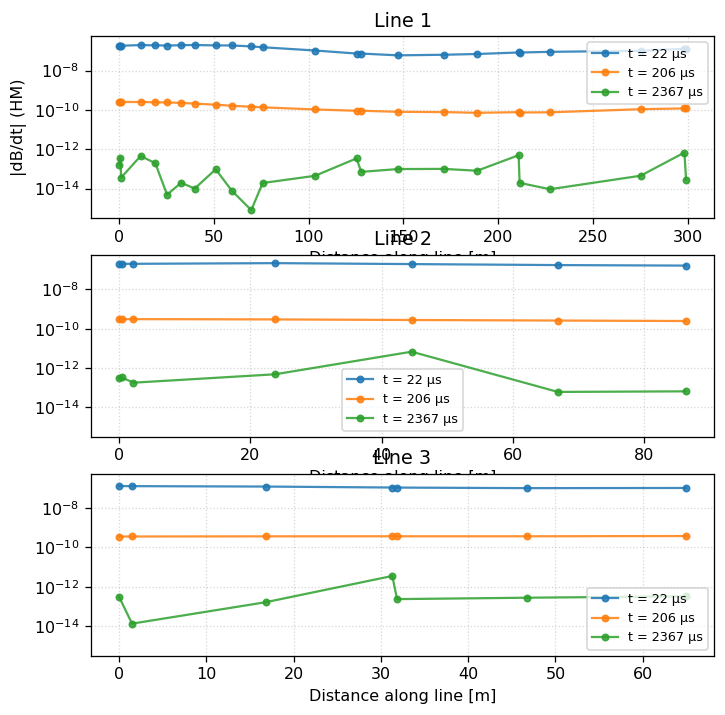

In [4]:
surv = Survey(tem)

# Per-gate SNR (scatter across stations) for each moment.
fig, axes = plt.subplots(1, len(surv.moments), figsize=(5 * len(surv.moments), 4), sharey=False)
axes = np.atleast_1d(axes)
for ax, moment in zip(axes, surv.moments):
    t_snr, mean, sem, snr = tem.snr(moment)
    ax.semilogx(t_snr, snr, 'o-', color='steelblue')
    ax.axhline(3, color='r', ls='--', lw=1, label='SNR = 3')
    ax.set_xlabel('Time [s]'); ax.set_ylabel('SNR [-]')
    ax.set_title(f'{moment} per-gate SNR')
    ax.grid(True, which='both', alpha=0.3); ax.legend()
fig.tight_layout()
plt.show()

surv.plot_soundings()
plt.show()

surv.plot_map()
plt.show()

surv.plot_transects('HM', n_gates=3)
plt.show()


## 2. Choose sounding, loop approximation, and model grid

`STATION = None` uses the stacked mean of all stations. Setting `STATION` to an integer uses one station row instead.

`USE_SQUARE_LOOP = False` uses the faster equal-area circular approximation. Set it to `True` when you want the square offset loop in the forward response. For development and method checks, the circular approximation is much faster.

In [5]:
LM_CURRENT = 1.0
HM_CURRENT = 10.0
CURRENTS = {'LM': LM_CURRENT, 'HM': HM_CURRENT}
MOMENTS = ['LM', 'HM']

STATION = None          # None = stacked mean; integer = station row index
USE_SQUARE_LOOP = False # False = equal-area circular offset loop; True = square offset loop

systems = {}
for moment in MOMENTS:
    systems[moment] = tem.to_pytem(moment, peak_current=CURRENTS[moment], station=STATION)

tx_side = float(systems['HM']['tx_size'])
tx_radius_equal_area = float(np.sqrt(tx_side**2 / np.pi))
rx_x = abs(float(systems['HM']['rx_x']))
rx_y = abs(float(systems['HM']['rx_y']))
geometry = 'square_offset' if USE_SQUARE_LOOP else 'circle_offset'
tx_size = tx_side if USE_SQUARE_LOOP else tx_radius_equal_area

print(f"Sounding : {'stacked mean' if STATION is None else f'station {STATION}'}")
print(f"Geometry : {geometry} | tx_side={tx_side:.2f} m | equal-area radius={tx_radius_equal_area:.2f} m | rx=({rx_x:.2f}, {rx_y:.2f}) m")
for moment, kw in systems.items():
    print(f"{moment}: gates={kw['times'].size:2d}, obs=[{kw['obs_data'].min():.2e}, {kw['obs_data'].max():.2e}] V/m², waveform peak={kw['waveform_currents'].max():.2f} A-turns")

Sounding : stacked mean
Geometry : circle_offset | tx_side=3.00 m | equal-area radius=1.69 m | rx=(13.00, 0.00) m
LM: gates= 6, obs=[1.30e-06, 1.02e-05] V/m², waveform peak=2.00 A-turns
HM: gates=22, obs=[4.84e-11, 2.56e-05] V/m², waveform peak=20.00 A-turns


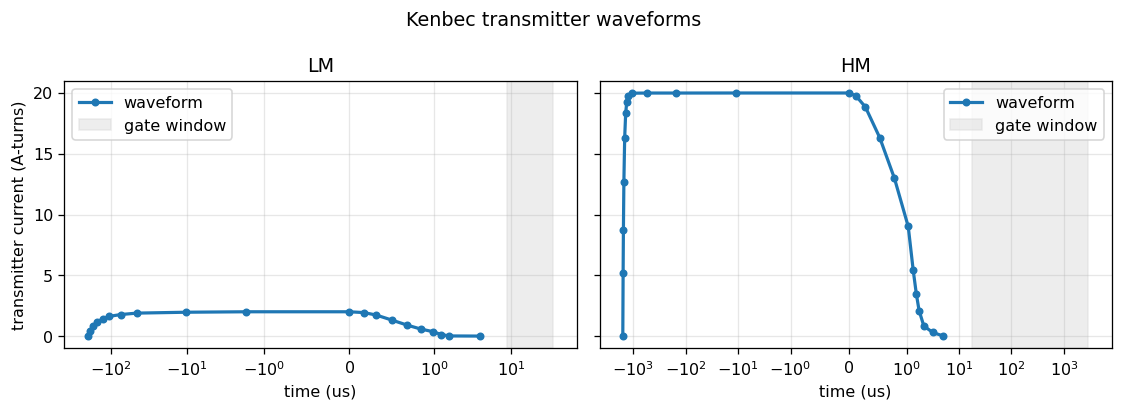

--- Waveform and frequency information ---

LM
  waveform points : 20
  time span       : -2.000e-04 to 4.000e-06 s
  peak current    : 2 A-turns
  gates           : 6 centres, 1.087e-05 to 2.943e-05 s
  gate window     : 8.900e-06 to 3.590e-05 s
  active ramps    : 18 segment(s)
  ramp durations  : 1.450e-07 to 3.540e-05 s
  approx ramp freq: 2.82e+04 to 6.9e+06 Hz (1/ramp duration)
  reciprocal gate band: 2.79e+04 to 1.12e+05 Hz (1/time, rough)

HM
  waveform points : 24
  time span       : -1.600e-03 to 5.000e-06 s
  peak current    : 20 A-turns
  gates           : 22 centres, 2.237e-05 to 2.367e-03 s
  gate window     : 1.790e-05 to 2.955e-03 s
  active ramps    : 21 segment(s)
  ramp durations  : 1.210e-07 to 4.954e-04 s
  approx ramp freq: 2.02e+03 to 8.26e+06 Hz (1/ramp duration)
  reciprocal gate band: 338 to 5.59e+04 Hz (1/time, rough)

Receiver/system frequency filter: none explicitly configured in this notebook cell state.


In [6]:
# Plot transmitter waveforms and summarize timing / frequency information
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(MOMENTS), figsize=(10, 3.6), sharey=True)
if len(MOMENTS) == 1:
    axes = [axes]

for ax, moment in zip(axes, MOMENTS):
    kw = systems[moment]
    wf_t = np.asarray(kw['waveform_times'], dtype=float)
    wf_I = np.asarray(kw['waveform_currents'], dtype=float)
    gates = np.asarray(kw['times'], dtype=float)
    gate_open = np.asarray(kw.get('gate_open', gates), dtype=float)
    gate_close = np.asarray(kw.get('gate_close', gates), dtype=float)

    ax.plot(wf_t * 1e6, wf_I, '-o', lw=2, ms=4, label='waveform')
    ax.axvspan(gate_open[0] * 1e6, gate_close[-1] * 1e6,
               color='0.85', alpha=0.45, label='gate window')
    ax.set_xscale('symlog', linthresh=1.0)
    ax.set_title(moment)
    ax.set_xlabel('time (us)')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='best')

axes[0].set_ylabel('transmitter current (A-turns)')
fig.suptitle('Kenbec transmitter waveforms')
fig.tight_layout()
plt.show()

print('--- Waveform and frequency information ---')
for moment in MOMENTS:
    kw = systems[moment]
    wf_t = np.asarray(kw['waveform_times'], dtype=float)
    wf_I = np.asarray(kw['waveform_currents'], dtype=float)
    gates = np.asarray(kw['times'], dtype=float)
    gate_open = np.asarray(kw.get('gate_open', gates), dtype=float)
    gate_close = np.asarray(kw.get('gate_close', gates), dtype=float)

    dt = np.diff(wf_t)
    dI = np.diff(wf_I)
    active = np.abs(dI) > 1e-12
    ramp_durations = np.abs(dt[active])

    print(f'\n{moment}')
    print(f'  waveform points : {wf_t.size}')
    print(f'  time span       : {wf_t.min():.3e} to {wf_t.max():.3e} s')
    print(f'  peak current    : {np.nanmax(wf_I):.3g} A-turns')
    print(f'  gates           : {gates.size} centres, {gates[0]:.3e} to {gates[-1]:.3e} s')
    print(f'  gate window     : {gate_open[0]:.3e} to {gate_close[-1]:.3e} s')

    if ramp_durations.size:
        f_ramp_min = 1.0 / ramp_durations.max()
        f_ramp_max = 1.0 / ramp_durations.min()
        print(f'  active ramps    : {ramp_durations.size} segment(s)')
        print(f'  ramp durations  : {ramp_durations.min():.3e} to {ramp_durations.max():.3e} s')
        print(f'  approx ramp freq: {f_ramp_min:.3g} to {f_ramp_max:.3g} Hz (1/ramp duration)')
    else:
        print('  active ramps    : none (constant waveform)')

    # Time gates imply a rough reciprocal frequency band sampled by the data.
    f_gate_low = 1.0 / gate_close[-1]
    f_gate_high = 1.0 / gate_open[0]
    print(f'  reciprocal gate band: {f_gate_low:.3g} to {f_gate_high:.3g} Hz (1/time, rough)')

# The current notebook setup does not define or pass a receiver/system filter.
# If a Butterworth/cascade filter is added later, its f_low/f_high values should be printed here.
print('\nReceiver/system frequency filter: none explicitly configured in this notebook cell state.')

In [7]:
systems['LM']['waveform_currents']

array([0.    , 0.4088, 0.7938, 1.1376, 1.434 , 1.621 , 1.7696, 1.889 ,
       1.962 , 2.    , 2.    , 1.9332, 1.7334, 1.326 , 0.9078, 0.585 ,
       0.3646, 0.1252, 0.011 , 0.    ])

## 3. Quintic B-spline matrix machinery (now in the base package)

In Christensen's terms, this cell builds the **system response** operator: the transmitter-waveform convolution and the finite receiver-gate averaging, assembled once into a fixed matrix that maps the **step response** to the predicted gate data. The convolution-free matrix method is now part of pyTEM as `pytem.setup_waveform_matrix`, so we import it instead of redefining it in the notebook. It has the same interface as `setup_waveform`:

```python
comp_times, apply_waveform = setup_waveform_matrix(gate_times, waveform_times, waveform_currents,
                                                   gate_open=..., gate_close=...)
pred = apply_waveform(step_response_at_comp_times)
```

`apply_waveform` is a single matrix multiply and exposes the underlying matrix as `apply_waveform.matrix`. If `gate_open` and `gate_close` are given, the matrix also performs the analytic receiver-gate average; otherwise it predicts at the gate centre times.

`PAD_DECADES` is not the speed control. It only decides how far the fixed log-time grid extends beyond the waveform and gate timing range. With `N_STEP` fixed, the forward model still evaluates the same number of step-response samples, so padding does not make the repeated inversion call faster. Too little padding can also make the spline edge support too tight and reduce agreement with `setup_waveform`. For speed, reduce `N_STEP`, use the analytical Jacobian, or reuse one shared step/Jacobian evaluation across LM/HM systems when they use the same geometry.


### How the quintic B-spline method uses numba / CUDA

The method is a **hybrid**: the expensive physics runs on pyTEM's accelerated kernels, while the convolution-free operator itself is intentionally plain NumPy.

| Component | Backend | Runs |
|---|---|---|
| Step response (`fwd_circle_offset` / `fwd_square_offset`, i.e. `fwd_step`) | CUDA > Numba > NumPy | every model, every iteration |
| Analytical Jacobian (`getJ_ana`) | CUDA > Numba > NumPy | every iteration |
| Waveform + gate matrix `M` (`setup_waveform_matrix`) | NumPy only | **once**, reused for all soundings |
| Matrix apply `M @ step` | NumPy / BLAS | every iteration (negligible) |

**What is accelerated.** The per-iteration cost is dominated by the step response and its Jacobian on the `t_step` grid. Both go through the numba-JIT kernels (`_tem_circular_grad_jit` / `_tem_square_grad_jit`) and can dispatch to CUDA. This is the part that scales with `N_STEP`, so it is exactly where acceleration matters.

**What is not accelerated, and why that is fine.** The quintic B-spline matrix machinery (`_build_waveform_matrix`, `_build_gating_matrix`, `quintic_b_spline`, the Gauss-Legendre gate integral) is single-threaded NumPy. But `M` is **model-independent**: it is built once and reused across every iteration and all 38 soundings, so it never enters the per-model hot loop. The apply step is a single BLAS matmul and is negligible.

**Backend dispatch caveat.** In pyTEM the GPU path activates only when numba is off:

```python
_use_gpu = HAS_CUDA and use_cuda and not _use_nb   # inversion.py
```

Because `use_numba` defaults to `True`, this notebook runs the **numba** Jacobian path. The calls here also pass `use_cuda=False` explicitly. To benchmark the CUDA Jacobian instead, call `getJ_ana(..., use_numba=False, use_cuda=True)` (requires a CUDA-capable GPU and CuPy).


In [8]:
from pytem import setup_waveform_matrix
from pytem.waveform import quintic_b_spline

# The quintic B-spline kernel, compact-support waveform matrix builder, Simpson
# kernel weights, and gate matrix all live in pytem.waveform. We only need
# setup_waveform_matrix here.


# N_STEP controls the fixed log-time grid sampled by the step response.
# This is the main speed/accuracy knob: smaller = faster, larger = more accurate.
N_STEP = 300

# N_DENSE_GATE controls only the internal quadrature used while building the
# gate-averaging matrix. It affects setup time, not the repeated forward cost.
N_DENSE_GATE = 400

# Number of samples per waveform ramp segment when converting the transmitter
# waveform into matrix weights.
N_KERNEL_PER_SEGMENT = 81

# PAD_DECADES controls how far the log-time grid extends beyond the data and
# waveform timing range. It is a coverage/warning knob, not a speed knob. With
# fixed N_STEP, lowering this does not reduce the number of expensive forward
# samples. PAD_DECADES = 1.0 keeps the LM/HM matrix comparison accurate here;
# 0.5 is too tight for LM, while 2.0 is wider but not faster.
PAD_DECADES = 1.0

## 4. Build LM and HM quintic B-spline system matrices

For each moment we create two matrices. `M_center` predicts the response at the gate centres and is used to compare against pyTEM's existing `setup_waveform`. `M_gate` predicts gate-averaged data using the gate open and close times from the Kenbec file.

The actual inversion-style data comparison below uses `M_gate`, because it includes both waveform and finite receiver gates in one matrix.

In [9]:
delay_sets = []
for kw in systems.values():
    waveform_times = np.asarray(kw['waveform_times'], dtype=float)
    waveform_currents = np.asarray(kw['waveform_currents'], dtype=float)
    active = np.flatnonzero(np.diff(waveform_currents) != 0.0)
    segment_endpoints = np.unique(np.concatenate([waveform_times[active], waveform_times[active + 1]]))
    output_times = np.concatenate([kw['times'], kw['gate_open'], kw['gate_close']])
    delays = output_times[:, None] - segment_endpoints[None, :]
    delay_sets.append(delays[delays > 0.0])

positive_delays = np.concatenate(delay_sets)
shared_t_step = np.logspace(
    np.log10(positive_delays.min()) - PAD_DECADES,
    np.log10(positive_delays.max()) + PAD_DECADES,
    N_STEP)

matrix_systems = {}
for moment, kw in systems.items():
    _, apply_center = setup_waveform_matrix(
        kw['times'], kw['waveform_times'], kw['waveform_currents'],
        t_step=shared_t_step, n_per_segment=N_KERNEL_PER_SEGMENT)

    _, apply_gate = setup_waveform_matrix(
        kw['times'], kw['waveform_times'], kw['waveform_currents'],
        gate_open=kw['gate_open'], gate_close=kw['gate_close'],
        t_step=shared_t_step, n_per_segment=N_KERNEL_PER_SEGMENT,
        n_dense_gate=N_DENSE_GATE)

    matrix_systems[moment] = dict(
        t_step=shared_t_step, apply_center=apply_center, apply_gate=apply_gate,
        M_center=apply_center.matrix, M_gate=apply_gate.matrix, kw=kw)
    Mg = apply_gate.matrix
    print(f"{moment}: t_step={shared_t_step.size}, M_gate={Mg.shape}, nonzero={100*np.count_nonzero(Mg)/Mg.size:.2f}%")

LM: t_step=300, M_gate=(6, 300), nonzero=28.22%
HM: t_step=300, M_gate=(22, 300), nonzero=20.08%


## 5. Compare the quintic B-spline matrix against pyTEM's standard waveform setup

This is the local sanity check before using the matrix with field data. We evaluate one starting model, predict LM and HM gates using the new matrix, and compare the centre-time matrix response against pyTEM's existing waveform quadrature.

The gate-averaged `M_gate` response will not be identical to the centre-time pyTEM comparison, because it includes finite gate averaging. The centre-time comparison isolates the waveform part of the new method.

LM: center matrix vs setup_waveform max diff = 0.000% | median = 0.000%
HM: center matrix vs setup_waveform max diff = 0.002% | median = 0.001%


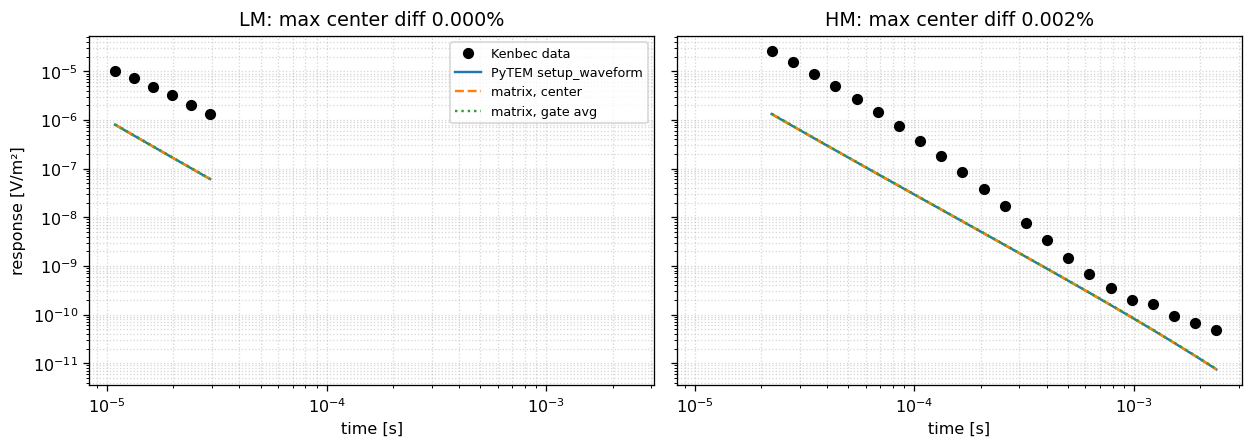

In [10]:
N_LAYERS = 15
thicknesses = np.logspace(np.log10(2.0), np.log10(25.0), N_LAYERS - 1)
depths_top = np.concatenate([[0.0], np.cumsum(thicknesses)])

rho_start = np.array([1.29553359e+01, 1.03984800e+01, 7.38912074e+00, 7.95289593e+00,
       5.40542388e+01, 4.09580754e+02, 2.12062062e+03, 7.34798218e+03,
       1.78703083e+04, 3.31014139e+04]) 

rho_start = np.ones_like(depths_top) * 100.0

def fwd_step(thick, rho, times):
    if USE_SQUARE_LOOP:
        return -fwd_square_offset(thick, rho, tx_size, rx_x, rx_y, times,
                                  current=1.0, signal=-1, n_quad=5, transform='dlf')
    return -fwd_circle_offset(thick, rho, tx_size, rx_x, times,
                              current=1.0, signal=-1, transform='dlf')

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, sharex=True)
for ax, moment in zip(axes, MOMENTS):
    ms = matrix_systems[moment]
    kw = ms['kw']
    step = fwd_step(thicknesses, rho_start, ms['t_step'])
    pred_center = ms['apply_center'](step)
    pred_gate = ms['apply_gate'](step)

    comp_t, apply_wf = setup_waveform(kw['times'], kw['waveform_times'], kw['waveform_currents'], n_quad=8)
    pred_pytem = apply_wf(fwd_step(thicknesses, rho_start, comp_t))
    rel = np.abs(pred_center - pred_pytem) / np.maximum(np.abs(pred_pytem), 1e-300)

    print(f"{moment}: center matrix vs setup_waveform max diff = {100*rel.max():.3f}% | median = {100*np.median(rel):.3f}%")

    ax.loglog(kw['times'], kw['obs_data'], 'ko', label='Kenbec data')
    ax.loglog(kw['times'], pred_pytem, '-', label='PyTEM setup_waveform')
    ax.loglog(kw['times'], pred_center, '--', label='matrix, center')
    ax.loglog(kw['times'], pred_gate, ':', label='matrix, gate avg')
    ax.set_title(f"{moment}: max center diff {100*rel.max():.3f}%")
    ax.set_xlabel('time [s]')
    ax.grid(True, which='both', ls=':', alpha=0.5)
axes[0].set_ylabel('response [V/m²]')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Build the joint LM + HM data vector

The same weighting rule from the Kenbec inversion notebook is used here: every retained gate gets a per-gate relative uncertainty. This avoids the bad RMS behavior caused by a global peak-relative noise floor.

In [11]:
MAX_NOISE = 0.50
NOISE_FLOOR_FRAC = 0.05

fit_systems = []
for moment in MOMENTS:
    kw = systems[moment]
    ms = matrix_systems[moment]
    obs = kw['obs_data']
    frac = kw['noise_std']
    frac_eff = np.maximum(frac, NOISE_FLOOR_FRAC)
    noise_abs = frac_eff * obs
    good = np.isfinite(obs) & np.isfinite(noise_abs) & (obs > 0) & (noise_abs > 0) & (frac <= MAX_NOISE)
    fit_systems.append(dict(name=moment, t_step=ms['t_step'], M=ms['M_gate'][good],
                            times=kw['times'][good], obs=obs[good], noise_abs=noise_abs[good],
                            good=good))
    print(f"{moment}: kept {good.sum()}/{good.size} gates | fractional noise range {100*np.nanmin(frac[good]):.1f}% to {100*np.nanmax(frac[good]):.1f}%")

LM: kept 6/6 gates | fractional noise range 3.7% to 6.0%
HM: kept 19/22 gates | fractional noise range 5.5% to 46.0%


## 7. Quick inversion with pyTEM alpha regularization

### Is the quintic B-spline matrix faster or slower?

**Faster per forward call, with a one-time build cost.** Measured on Kenbec LM (`N_STEP = 300`):

| method | step-response points | per forward call | one-time build |
|---|---|---|---|
| `setup_waveform` (standard) | 864 | ~558 ms | ~2 ms |
| `setup_waveform_matrix` (quintic B-spline) | 300 | ~194 ms | ~1.3 s |

Both methods end as a matrix multiply, so the matmul itself is negligible. The real cost is the step-response forward (the DLF Hankel transform), which scales with the number of time points. `setup_waveform` needs the step response at 864 deduplicated Gauss-Legendre quadrature times; the quintic B-spline matrix needs it only on a **fixed grid you control** through `N_STEP`. Fewer points means a faster forward, so here this path is roughly **3x faster per iteration**. The build is a one-time cost that amortizes across an inversion, and the number of waveform/system-response samples no longer affects forward cost at all.

### Why the result depends on the starting model

The sensitivity comes from this quick inversion, not the matrix method:

- The Jacobian is finite-differenced in log-resistivity, so it is only locally valid.
- Near-zero predicted gates are floored at `1e-300`, which can create large residuals early on.
- Regularization choice matters: pulling toward the starting model biases the answer toward it.

### Using the pyTEM alpha value

This version uses pyTEM's own regularization instead of an ad-hoc damping ladder:

- `getR` builds the first-order roughness (smoothness) matrix.
- `getAlphas` turns a single scalar `alpha` into a **depth-weighted** per-layer regularization vector.
- `_gn_solve` solves the weighted, regularized Gauss-Newton step, anchoring model *roughness* toward zero (smoothness) rather than pulling toward the starting model, which reduces start-model bias.
- `alpha` is initialized from the gradient norm and **cooled** each iteration on a log-spaced ladder (`getAlpha`), exactly like `pytem.invert`.

### Why the "non-positive dbdt values (zeroed in J)" warning appears

`getJ_ana` returns a **log-space** Jacobian, $d\ln(\text{response}) / d\ln\rho$. That is only defined where the step response is positive, so internally it forms `f0 = -dbdt` and zeroes any row where `f0 <= 0`, printing the count as a warning.

For an **offset** loop (the receiver is displaced from the transmitter, here `rx_x = 13 m`), the vertical $dB_z/dt$ is not sign-definite. At certain times the field seen at the offset receiver reverses sign, the classic offset-loop sign reversal. On the fixed log-time grid `t_step`, some samples fall on the wrong side of that sign change, so their `-dbdt` is non-positive and get zeroed.

Key points:

- - These are internal `t_step` **grid rows**, not your data gates. The quintic B-spline matrix `M` only samples the step response; a gate that combines positive samples is still fine, which is why the inversion still converges.
- Zeroing a few grid rows just removes their sensitivity contribution. As long as enough valid rows remain, each layer's Jacobian column is still well constrained.
- `PAD_DECADES` changes **how many** rows are zeroed, not the speed. A tighter grid keeps `t_step` inside the physically positive time range and avoids the far early/late samples where the sign flips, so fewer rows are zeroed. That is what you saw when the padding reduced the warnings.
- The warning is informational. It only matters if a large fraction of the grid is zeroed (which would flatten sensitivity). A handful of zeroed rows out of `N_STEP = 300` is harmless.

In [12]:
from pytem import getR, getJ_ana
from pytem.inversion import _alpha_search

RUN_QUICK_INVERSION = True
USE_ANALYTICAL_JACOBIAN = True   # True = getJ_ana chained through M; False = finite diff
MAXIT = 8
FD_EPS = 0.02
ALPHA_STEPS = 6          # number of alpha rungs tested per iteration
ALPHA_STEP = 1 / 3       # log10 decrement per rung (getAlpha)
RHO_MIN, RHO_MAX = 0.5, 1e5
#MAX_NOISE = 0.040

# Main square-loop speed knob. The square offset integrates the full
# n_quad x n_quad grid of point sources, so BOTH the forward and the
# analytical Jacobian cost scale as N_QUAD_SQUARE**2 per time sample:
#   n_quad = 5 -> 25 kernel passes/time  (accurate, slow)
#   n_quad = 4 -> 16 kernel passes/time  (~1.6x faster)
#   n_quad = 3 ->  9 kernel passes/time  (~2.8x faster, coarser)
# The circular offset ignores this knob (single Hankel pass per time).
N_QUAD_SQUARE = 3

# Inversion geometry override:
#   None            -> use geometry from Cell 2
#   'circle_offset' -> circular offset forward/Jacobian (fast, single pass)
#   'square_offset' -> square offset forward/Jacobian (slow, n_quad**2 passes)
INVERSION_GEOMETRY = 'circle_offset'

# Jacobian backend switches. On most cases here, numba is faster than cuda.
JAC_USE_NUMBA = True
JAC_USE_CUDA = False

# Cell-18 sounding selector:
# None -> stacked mean, integer -> specific station index.
QUICK_STATION = 4

if QUICK_STATION is None:
    quick_station_label = 'stacked mean'
else:
    quick_station_label = f'station {int(QUICK_STATION)}'

if INVERSION_GEOMETRY is None:
    geometry_inv = geometry
elif INVERSION_GEOMETRY in ('circle_offset', 'square_offset'):
    geometry_inv = INVERSION_GEOMETRY
else:
    raise ValueError("INVERSION_GEOMETRY must be None, 'circle_offset', or 'square_offset'")

# Keep geometry-dependent tx size consistent with Cell 2 definitions.
tx_size_inv = tx_radius_equal_area if geometry_inv == 'circle_offset' else tx_side

# Rebuild fit systems in this cell so quick inversion can choose its own sounding.
quick_systems = {}
for moment in MOMENTS:
    quick_systems[moment] = tem.to_pytem(moment, peak_current=CURRENTS[moment], station=QUICK_STATION)

fit_systems = []
for moment in MOMENTS:
    kw = quick_systems[moment]
    ms = matrix_systems[moment]
    obs = kw['obs_data']
    frac = kw['noise_std']
    frac_eff = np.maximum(frac, NOISE_FLOOR_FRAC)
    noise_abs = frac_eff * obs
    good = np.isfinite(obs) & np.isfinite(noise_abs) & (obs > 0) & (noise_abs > 0) & (frac <= MAX_NOISE)
    fit_systems.append(dict(name=moment, t_step=ms['t_step'], M=ms['M_gate'][good],
                            times=kw['times'][good], obs=obs[good], noise_abs=noise_abs[good],
                            good=good))

print(f"Quick inversion sounding: {quick_station_label}")
print(f"Inversion geometry: {geometry_inv} (n_quad={N_QUAD_SQUARE})")
print(f"Jacobian backend: numba={JAC_USE_NUMBA}, cuda={JAC_USE_CUDA}")
for fs in fit_systems:
    print(f"  {fs['name']}: kept {fs['obs'].size} gates")

def fwd_step_inv(thick, rho, times):
    if geometry_inv == 'square_offset':
        return -fwd_square_offset(thick, rho, tx_size_inv, rx_x, rx_y, times,
                                  current=1.0, signal=-1, n_quad=N_QUAD_SQUARE,
                                  use_numba=JAC_USE_NUMBA, use_cuda=JAC_USE_CUDA,
                                  transform='dlf')
    return -fwd_circle_offset(thick, rho, tx_size_inv, rx_x, times,
                              current=1.0, signal=-1,
                              use_numba=JAC_USE_NUMBA, use_cuda=JAC_USE_CUDA,
                              transform='dlf')

# One-entry model cache shared by prediction and the analytical Jacobian.
# Every fitted system uses the same shared step-time basis and its own gate matrix.
_model_cache = {'key': None, 'step': None, 'jacobian_abs': None}

def model_cache_for(log_rho):
    key = np.asarray(log_rho, dtype=float).tobytes()
    if _model_cache['key'] != key:
        _model_cache['key'] = key
        _model_cache['step'] = fwd_step_inv(thicknesses, np.exp(log_rho), shared_t_step)
        _model_cache['jacobian_abs'] = None
    return _model_cache

def predict_all(log_rho):
    """Quintic B-spline matrix forward: positive gate response for all systems."""
    step = model_cache_for(log_rho)['step']
    return np.concatenate([fs['M'] @ step for fs in fit_systems])

obs_all = np.concatenate([fs['obs'] for fs in fit_systems])
noise_all = np.concatenate([fs['noise_abs'] for fs in fit_systems])
w_all = obs_all / noise_all

def weighted_log_rms(pred):
    residual = np.log(obs_all) - np.log(np.maximum(pred, 1e-300))
    return np.sqrt(np.mean((w_all * residual) ** 2)), residual

def fd_log_jacobian(log_rho, pred0):
    """Finite-difference log-space Jacobian of the stacked gate response."""
    J = np.zeros((pred0.size, log_rho.size))
    log_pred0 = np.log(np.maximum(pred0, 1e-300))
    for j in range(log_rho.size):
        mp = log_rho.copy()
        mp[j] += FD_EPS
        predp = predict_all(mp)
        J[:, j] = (np.log(np.maximum(predp, 1e-300)) - log_pred0) / FD_EPS
    return J

def ana_log_jacobian(log_rho, pred0):
    """Analytical log-space Jacobian of the stacked gate response."""
    cached = model_cache_for(log_rho)
    if cached['jacobian_abs'] is None:
        cached['jacobian_abs'] = getJ_ana(
            thicknesses=thicknesses,
            log_resistivities=log_rho,
            tx_size=tx_size_inv,
            times=shared_t_step,
            geometry=geometry_inv,
            rx_x=rx_x,
            rx_y=rx_y,
            n_quad=N_QUAD_SQUARE,
            use_numba=JAC_USE_NUMBA,
            use_cuda=JAC_USE_CUDA,
            transform='dlf',
            jacobian_mode='absolute',
        )
    dgate = np.vstack([fs['M'] @ cached['jacobian_abs'] for fs in fit_systems])
    J = np.zeros_like(dgate)
    positive = pred0 > 0
    J[positive, :] = dgate[positive, :] / pred0[positive, None]
    return J

def compute_jacobian(log_rho, pred0):
    if USE_ANALYTICAL_JACOBIAN:
        return ana_log_jacobian(log_rho, pred0)
    return fd_log_jacobian(log_rho, pred0)

ln_lo, ln_hi = np.log(RHO_MIN), np.log(RHO_MAX)
m = np.log(rho_start.copy())
R = getR(rho_start)                       # first-order smoothness matrix
rms_history = []
accepted_rms_history = []
alpha_history = []
inversion_status = 'not run'
print(f"Jacobian mode: {'analytical (getJ_ana @ M)' if USE_ANALYTICAL_JACOBIAN else 'finite difference'}")

if RUN_QUICK_INVERSION:
    inversion_status = 'running'

    # Initialise alpha from the gradient norm, exactly like pytem.invert.
    pred0 = predict_all(m)
    _, res0 = weighted_log_rms(pred0)
    J0 = compute_jacobian(m, pred0)
    Jw0 = J0 * w_all[:, None]
    dw0 = w_all * res0
    alpha_start = float(np.linalg.norm(Jw0.T @ dw0, np.inf) + 1e-30)
    print(f"alpha start = {alpha_start:.3e}\n")

    for it in range(MAXIT):
        pred = predict_all(m)
        rms, residual = weighted_log_rms(pred)
        rms_history.append(rms)
        print(f"Iteration {it + 1}:  RMS = {rms:.3f}")

        if rms <= 1.0:
            accepted_rms_history.append(rms)
            inversion_status = 'converged'
            break

        J = compute_jacobian(m, pred)
        Jw = J * w_all[:, None]
        dw = w_all * residual

        # pyTEM alpha search: ladder of alphas + parabola fit to RMS = 1.
        alpha_h, rms_h, delta_h, mod_h = _alpha_search(
            alpha_start, ALPHA_STEPS, Jw, dw, R, m,
            thicknesses, predict_all, obs_all, w_all,
            ln_lo, ln_hi, alpha_step=ALPHA_STEP, rms_current=rms, plot=False,
        )

        # Occam selection: prefer the parabola (overshoot) entry, else the
        # largest alpha still reaching RMS <= 1, else the minimum-RMS rung.
        rms_arr = np.array(rms_h)
        overshoot = bool(np.any(rms_arr < 1.0))
        if overshoot:
            best_idx = len(rms_h) - 1
        else:
            below = rms_arr[rms_arr <= 1.0]
            if below.size > 0:
                best_idx = int(np.where(rms_arr == below.max())[0][-1])
            else:
                best_idx = int(np.argmin(rms_arr))

        if rms_h[best_idx] >= rms:
            print("  No improvement found - stopping.")
            inversion_status = 'stopped: no improving step'
            accepted_rms_history.append(rms)
            break

        m = np.clip(m + delta_h[best_idx], ln_lo, ln_hi)
        accepted_rms_history.append(rms_h[best_idx])
        alpha_history.append(alpha_h[best_idx])
        # Cool alpha_start one rung above the best alpha found.
        alpha_start = alpha_h[best_idx] * (10.0 ** ALPHA_STEP)

        if overshoot:
            inversion_status = 'converged'
            break
    else:
        inversion_status = 'max iterations reached'
else:
    pred0 = predict_all(m)
    rms0, _ = weighted_log_rms(pred0)
    rms_history.append(rms0)
    accepted_rms_history.append(rms0)
    inversion_status = 'not run: showing starting model'
    print('Set RUN_QUICK_INVERSION = True to run the finite-difference test inversion.')

rho_result = np.exp(m)
final_pred = predict_all(m)
final_rms, _ = weighted_log_rms(final_pred)
print(f'\ninversion_status: {inversion_status}')
print(f'final RMS: {final_rms:.3f}')
print('rho_result [Ohm m]:', np.round(rho_result, 2))


Quick inversion sounding: station 4
Inversion geometry: circle_offset (n_quad=3)
Jacobian backend: numba=True, cuda=False
  LM: kept 6 gates
  HM: kept 20 gates
Jacobian mode: analytical (getJ_ana @ M)
alpha start = 3.922e+03

Iteration 1:  RMS = 51.155
    Alpha = 3922.41,  RMS = 17.05
    Alpha = 1820.62,  RMS = 17.77
    RMS increased - stopping alpha search early.
Iteration 2:  RMS = 17.046
    Alpha = 8450.58,  RMS = 7.44
    Alpha = 3922.41,  RMS = 5.63
    Alpha = 1820.62,  RMS = 5.07
    Alpha = 845.06,  RMS = 5.10
    RMS increased - stopping alpha search early.
Iteration 3:  RMS = 5.072
    Alpha = 3922.41,  RMS = 4.58
    Alpha = 1820.62,  RMS = 3.44
    Alpha = 845.06,  RMS = 3.02
    Alpha = 392.24,  RMS = 2.92
    Alpha = 182.06,  RMS = 3.16
    RMS increased - stopping alpha search early.
Iteration 4:  RMS = 2.924
    Alpha = 845.06,  RMS = 3.72
    Alpha = 392.24,  RMS = 2.82
    Alpha = 182.06,  RMS = 2.38
    Alpha = 84.51,  RMS = 2.42
    RMS increased - stopping alp

In [13]:
#batch inversion



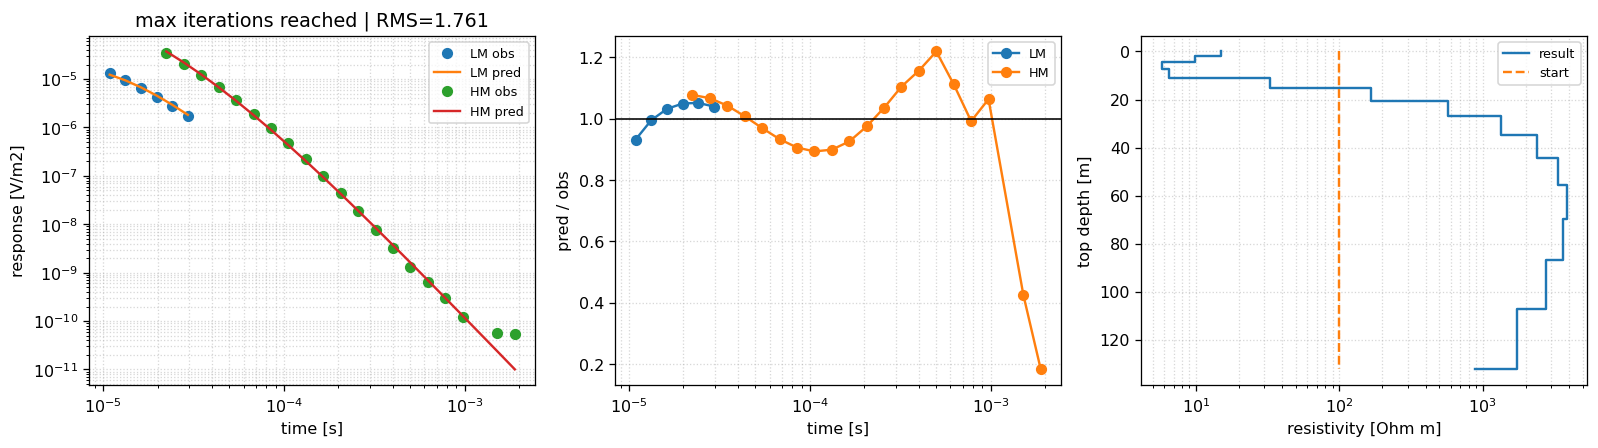

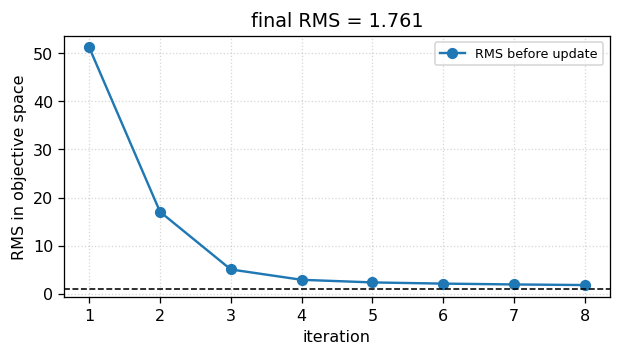

In [14]:
pred_all = predict_all(np.log(rho_result))
plot_rms, _ = weighted_log_rms(pred_all)

offset = 0
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for fs in fit_systems:
    n = fs['obs'].size
    pred = pred_all[offset:offset+n]
    obs = fs['obs']
    t = fs['times']
    offset += n

    axes[0].loglog(t, obs, 'o', label=f"{fs['name']} obs")
    axes[0].loglog(t, pred, '-', label=f"{fs['name']} pred")
    axes[1].semilogx(t, pred / np.maximum(obs, 1e-300), 'o-', label=fs['name'])

axes[0].set_title(f"{inversion_status} | RMS={plot_rms:.3f}")
axes[0].set_xlabel('time [s]')
axes[0].set_ylabel('response [V/m2]')
axes[0].grid(True, which='both', ls=':', alpha=0.5)
axes[0].legend(fontsize=8)

axes[1].axhline(1.0, color='k', lw=1)
axes[1].set_ylabel('pred / obs')
axes[1].set_xlabel('time [s]')
axes[1].grid(True, which='both', ls=':', alpha=0.5)
axes[1].legend(fontsize=8)

axes[2].step(rho_result, depths_top, where='pre', label='result')
axes[2].step(rho_start, depths_top, where='pre', ls='--', label='start')
axes[2].set_xscale('log')
axes[2].invert_yaxis()
axes[2].set_xlabel('resistivity [Ohm m]')
axes[2].set_ylabel('top depth [m]')
axes[2].grid(True, which='both', ls=':', alpha=0.5)
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

if rms_history:
    plt.figure(figsize=(5.5, 3.2))
    plt.plot(np.arange(1, len(rms_history) + 1), rms_history, 'o-', label='RMS before update')
    plt.axhline(1.0, color='k', lw=1, ls='--')
    plt.xlabel('iteration')
    plt.ylabel('RMS in objective space')
    plt.title(f'final RMS = {plot_rms:.3f}')
    plt.grid(True, ls=':', alpha=0.5)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

### Classical quadrature versus quintic B-spline inversion
This comparison isolates **waveform handling**. Both inversions use the same selected sounding, retained LM/HM gates, starting model, loop geometry, analytical Jacobian, six-step alpha ladder, bounds, and stopping rule. Only the waveform operator changes:

- **Classical:** `setup_waveform` evaluates the step response and absolute analytical Jacobian at the Gauss-Legendre quadrature delays required by each moment.
- **Quintic B-spline:** `M_center` maps one shared fixed-grid step response and absolute analytical Jacobian to both moments.

Gate-centre predictions are used for both methods so finite receiver-gate averaging does not confound the comparison. The main production inversion above still uses `M_gate` and therefore includes the measured gate widths.

The output compares setup cost, total inversion time, final RMS, recovered resistivity, and final predicted data. `COMPARE_MAXIT` and `COMPARE_STATION` can be changed without affecting the batch inversion below.


In [15]:
# Stabilize CPU threading before timing the waveform comparison.
import os
import sys

try:
    import numba as _compare_numba
except Exception:
    _compare_numba = None

COMPARE_NUMBA_THREADS = min(8, os.cpu_count() or 1)
if _compare_numba is not None:
    COMPARE_NUMBA_THREADS = min(
        COMPARE_NUMBA_THREADS, _compare_numba.config.NUMBA_DEFAULT_NUM_THREADS)
    _compare_numba.set_num_threads(COMPARE_NUMBA_THREADS)
    effective_compare_threads = _compare_numba.get_num_threads()
else:
    effective_compare_threads = 1

print(f'Comparison runtime: Python={sys.executable}')
print(f'Comparison runtime: logical CPUs={os.cpu_count()}, '
      f'Numba threads={effective_compare_threads}')
print('Run this cell immediately before the comparison; do not run another '
      'parallel inversion between these two cells.')

Comparison runtime: Python=c:\WPy64-31180\python-3.11.8.amd64\python.exe
Comparison runtime: logical CPUs=12, Numba threads=8
Run this cell immediately before the comparison; do not run another parallel inversion between these two cells.


In [16]:
import time

RUN_WAVEFORM_COMPARISON = False
COMPARE_STATION = QUICK_STATION if QUICK_STATION is not None else 4
COMPARE_MAXIT = MAXIT
CLASSIC_N_QUAD = 8


def _comparison_data(station):
    data = []
    for moment in MOMENTS:
        kw = tem.to_pytem(moment, peak_current=CURRENTS[moment], station=station)
        obs = np.asarray(kw['obs_data'], dtype=float)
        frac = np.asarray(kw['noise_std'], dtype=float)
        noise_abs = np.maximum(frac, NOISE_FLOOR_FRAC) * obs
        good = (np.isfinite(obs) & np.isfinite(noise_abs) & (obs > 0)
                & (noise_abs > 0) & (frac <= MAX_NOISE))
        data.append(dict(moment=moment, kw=kw, good=good, times=kw['times'][good],
                         obs=obs[good], noise_abs=noise_abs[good]))
    return data


comparison_data = _comparison_data(COMPARE_STATION)

t_setup = time.perf_counter()
classic_ops = []
for item in comparison_data:
    kw = item['kw']
    comp_times, apply_waveform = setup_waveform(
        item['times'], kw['waveform_times'], kw['waveform_currents'],
        n_quad=CLASSIC_N_QUAD)
    classic_ops.append(dict(name=item['moment'], times=comp_times,
                            apply=apply_waveform, obs=item['obs'],
                            noise_abs=item['noise_abs'], gate_times=item['times']))
classic_setup_seconds = time.perf_counter() - t_setup

t_setup = time.perf_counter()
matrix_ops = []
for item in comparison_data:
    kw = item['kw']
    _, apply_waveform = setup_waveform_matrix(
        kw['times'], kw['waveform_times'], kw['waveform_currents'],
        t_step=shared_t_step, n_per_segment=N_KERNEL_PER_SEGMENT)
    M = apply_waveform.matrix[item['good']]
    matrix_ops.append(dict(name=item['moment'], times=shared_t_step,
                           apply=lambda values, M=M: M @ values, obs=item['obs'],
                           noise_abs=item['noise_abs'], gate_times=item['times']))
matrix_setup_seconds = time.perf_counter() - t_setup


def invert_waveform_method(operators, shared_physics, label):
    """Invert one sounding while changing only the waveform operator."""
    obs = np.concatenate([op['obs'] for op in operators])
    noise = np.concatenate([op['noise_abs'] for op in operators])
    weights = obs / noise
    cache = {'key': None, 'steps': None, 'jacobians': None}

    def model_terms(log_rho, need_jacobian=False):
        key = np.asarray(log_rho, dtype=float).tobytes()
        if cache['key'] != key:
            grids = [operators[0]['times']] if shared_physics else [op['times'] for op in operators]
            cache['key'] = key
            cache['steps'] = [
                fwd_step_inv(thicknesses, np.exp(log_rho), grid) for grid in grids
            ]
            cache['jacobians'] = None
        if need_jacobian and cache['jacobians'] is None:
            grids = [operators[0]['times']] if shared_physics else [op['times'] for op in operators]
            cache['jacobians'] = [
                getJ_ana(
                    thicknesses=thicknesses, log_resistivities=log_rho,
                    tx_size=tx_size_inv, times=grid, geometry=geometry_inv,
                    rx_x=rx_x, rx_y=rx_y, n_quad=N_QUAD_SQUARE,
                    use_numba=JAC_USE_NUMBA, use_cuda=JAC_USE_CUDA,
                    transform='dlf', jacobian_mode='absolute')
                for grid in grids
            ]
        return cache

    def predict(log_rho):
        terms = model_terms(log_rho)
        if shared_physics:
            return np.concatenate([op['apply'](terms['steps'][0]) for op in operators])
        return np.concatenate([
            op['apply'](step) for op, step in zip(operators, terms['steps'])
        ])

    def objective(prediction):
        residual = np.log(obs) - np.log(np.maximum(prediction, 1e-300))
        return np.sqrt(np.mean((weights * residual) ** 2)), residual

    def jacobian(log_rho, prediction):
        terms = model_terms(log_rho, need_jacobian=True)
        if shared_physics:
            absolute = np.vstack([
                op['apply'](terms['jacobians'][0]) for op in operators
            ])
        else:
            absolute = np.vstack([
                op['apply'](J_abs)
                for op, J_abs in zip(operators, terms['jacobians'])
            ])
        J_log = np.zeros_like(absolute)
        positive = prediction > 0
        J_log[positive] = absolute[positive] / prediction[positive, None]
        return J_log

    lower, upper = np.log(RHO_MIN), np.log(RHO_MAX)
    model = np.log(np.asarray(rho_start, dtype=float).copy())
    roughness = getR(rho_start)
    history = []
    started = time.perf_counter()

    prediction = predict(model)
    rms, residual = objective(prediction)
    J_weighted = jacobian(model, prediction) * weights[:, None]
    alpha = float(np.linalg.norm(J_weighted.T @ (weights * residual), np.inf) + 1e-30)
    status = 'max iterations reached'

    print(f"\n{label}: setup complete, starting RMS={rms:.3f}")
    for iteration in range(COMPARE_MAXIT):
        prediction = predict(model)
        rms, residual = objective(prediction)
        history.append(rms)
        print(f"  iteration {iteration + 1}: RMS={rms:.3f}")
        if rms <= 1.0:
            status = 'converged'
            break

        J_weighted = jacobian(model, prediction) * weights[:, None]
        alpha_h, rms_h, delta_h, _ = _alpha_search(
            alpha, ALPHA_STEPS, J_weighted, weights * residual, roughness, model,
            thicknesses, predict, obs, weights, lower, upper,
            alpha_step=ALPHA_STEP, rms_current=rms, plot=False)

        rms_array = np.asarray(rms_h)
        alpha_array = np.asarray(alpha_h)
        acceptable = np.flatnonzero(rms_array <= 1.0)
        if acceptable.size:
            best = int(acceptable[np.argmax(alpha_array[acceptable])])
        else:
            best = int(np.argmin(rms_array))

        if rms_h[best] >= rms:
            status = 'stopped: no improving step'
            break

        model = np.clip(model + delta_h[best], lower, upper)
        alpha = alpha_h[best] * (10.0 ** ALPHA_STEP)
        if rms_h[best] <= 1.0:
            status = 'converged'
            break

    final_prediction = predict(model)
    final_rms, _ = objective(final_prediction)
    return dict(label=label, rho=np.exp(model), pred=final_prediction,
                rms=final_rms, status=status, history=np.asarray(history),
                seconds=time.perf_counter() - started, operators=operators)


if RUN_WAVEFORM_COMPARISON:
    classic_result = invert_waveform_method(
        classic_ops, shared_physics=False, label='Classical quadrature')

    matrix_result = invert_waveform_method(
        matrix_ops, shared_physics=True, label='Quintic B-spline')
    model_rel = np.linalg.norm(matrix_result['rho'] - classic_result['rho']) / np.linalg.norm(classic_result['rho'])
    pred_rel = np.linalg.norm(matrix_result['pred'] - classic_result['pred']) / np.linalg.norm(classic_result['pred'])

    print('\nWaveform inversion comparison')
    print(f"{'method':<24} {'setup [s]':>10} {'invert [s]':>11} {'RMS':>9}  status")
    print(f"{'classical quadrature':<24} {classic_setup_seconds:10.3f} {classic_result['seconds']:11.3f} {classic_result['rms']:9.3f}  {classic_result['status']}")
    print(f"{'quintic B-spline':<24} {matrix_setup_seconds:10.3f} {matrix_result['seconds']:11.3f} {matrix_result['rms']:9.3f}  {matrix_result['status']}")
    print(f"speedup (inversion only): {classic_result['seconds'] / max(matrix_result['seconds'], 1e-12):.2f}x")
    print(f"relative model L2 difference: {100 * model_rel:.3f}%")
    print(f"relative prediction L2 difference: {100 * pred_rel:.3f}%")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    axes[0].step(classic_result['rho'], depths_top, where='pre', label='classical')
    axes[0].step(matrix_result['rho'], depths_top, where='pre', ls='--', label='quintic B-spline')
    axes[0].step(rho_start, depths_top, where='pre', color='0.5', ls=':', label='start')
    axes[0].set_xscale('log')
    axes[0].invert_yaxis()
    axes[0].set_xlabel('resistivity [Ohm m]')
    axes[0].set_ylabel('top depth [m]')
    axes[0].set_title(f'model difference: {100 * model_rel:.2f}%')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, which='both', ls=':', alpha=0.4)

    axes[1].plot(np.arange(1, classic_result['history'].size + 1), classic_result['history'], 'o-', label='classical')
    axes[1].plot(np.arange(1, matrix_result['history'].size + 1), matrix_result['history'], 's--', label='quintic B-spline')
    axes[1].axhline(1.0, color='k', lw=1, ls=':')
    axes[1].set_xlabel('iteration')
    axes[1].set_ylabel('weighted log RMS')
    axes[1].set_title('convergence')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, ls=':', alpha=0.4)

    offset = 0
    colors = {'LM': 'tab:blue', 'HM': 'tab:red'}
    for item in comparison_data:
        count = item['obs'].size
        selection = slice(offset, offset + count)
        color = colors[item['moment']]
        axes[2].loglog(item['times'], item['obs'], 'o', color=color, ms=4, label=f"{item['moment']} data")
        axes[2].loglog(item['times'], classic_result['pred'][selection], '-', color=color, label=f"{item['moment']} classical")
        axes[2].loglog(item['times'], matrix_result['pred'][selection], '--', color=color, label=f"{item['moment']} quintic B-spline")
        offset += count
    axes[2].set_xlabel('time [s]')
    axes[2].set_ylabel('response [V/m2]')
    axes[2].set_title('final predictions')
    axes[2].legend(fontsize=7, ncol=2)
    axes[2].grid(True, which='both', ls=':', alpha=0.4)

    fig.suptitle(f'Waveform handling comparison, station {COMPARE_STATION}')
    fig.tight_layout()
    plt.show()
else:
    print('Set RUN_WAVEFORM_COMPARISON = True to run both inversions.')

Set RUN_WAVEFORM_COMPARISON = True to run both inversions.


### Waveform comparison result

For the controlled station-4 inversion, classical Gauss-Legendre waveform quadrature and the quintic B-spline matrix produced effectively the same result: final RMS `2.228`, relative model L2 difference `0.038%`, and relative prediction L2 difference below the printed `0.001%` precision. The classical inversion took `892.445 s`; the quintic B-spline inversion took `81.702 s`, a measured inversion-only speedup of `10.92x`.

The matrix setup cost was larger (`0.518 s` versus `0.002 s`) but is paid once and is negligible over a full inversion. This comparison uses gate-centre predictions for both methods, so it isolates waveform handling rather than finite receiver-gate averaging.

## 8. Invert every sounding, reusing the quintic B-spline matrices

Every Kenbec station shares the same transmitter waveform, gate timing, and geometry; only the measured dB/dt changes from station to station. That means the LM and HM quintic B-spline matrices `M_gate` built in section 4 are **identical for every sounding**, so we build them once and reuse them for all stations.

For each station we still evaluate the step response and the analytical Jacobian on the shared `t_step` grid (those depend on the resistivity model), then apply the same fixed matrices with `M @ step`. The expensive matrix build is paid once, not per station, and each sounding runs the same `_alpha_search` solver used above.

This is the multi-dataset pattern taken one step further: LM and HM are two datasets stacked onto one shared model, and here we loop that same joint solver over all 38 soundings. The per-station `getJ_ana` warnings are suppressed during the loop to keep the output readable.

The starting model is only the initial guess. The regularization is on model roughness, not on deviation from the start model, so a homogeneous start model is allowed and should not be penalized just for departing from it.

In [17]:
import os, time, threading, sys
import concurrent.futures as _cf

try:
    import numba as _numba
except Exception:
    _numba = None

# One inversion control: beta=0 gives independent 1D inversions; beta>0
 # enables distance-weighted coupling while retaining one alpha per sounding.
SPATIAL_BETA = 0.0
SELECT_STATION = None
MAX_STATIONS = None
MAXIT = 15
N_WORKERS = min(os.cpu_count() or 4, 8)

if SPATIAL_BETA < 0:
    raise ValueError('SPATIAL_BETA must be non-negative.')


def station_fit_systems(station):
    """Build LM + HM fit systems for one station using shared waveform matrices."""
    fit_systems = []
    for moment in MOMENTS:
        kwargs = tem.to_pytem(
            moment, peak_current=CURRENTS[moment], station=station)
        matrix_system = matrix_systems[moment]
        observed = kwargs['obs_data']
        fractional_noise = kwargs['noise_std']
        noise_absolute = np.maximum(fractional_noise, NOISE_FLOOR_FRAC) * observed
        good = (np.isfinite(observed) & np.isfinite(noise_absolute)
                & (observed > 0) & (noise_absolute > 0)
                & (fractional_noise <= MAX_NOISE))
        fit_systems.append({
            'name': moment,
            'M': matrix_system['M_gate'][good],
            'times': kwargs['times'][good],
            'obs': observed[good],
            'noise_abs': noise_absolute[good],
        })
    return fit_systems


# All sites have the same model and forward configuration at iteration 1.
# Compute the expensive absolute step-response Jacobian once. Each site still
# applies its own gate rows, prediction normalization, and data weights.
_initial_log_rho = np.log(np.asarray(rho_start, dtype=float))
_initial_jacobian_abs = None
_initial_jacobian_lock = threading.Lock()
_getJ_ana_model_specific = getJ_ana


def _shared_initial_jacobian():
    global _initial_jacobian_abs
    if _initial_jacobian_abs is None:
        with _initial_jacobian_lock:
            if _initial_jacobian_abs is None:
                print('Computing one shared first-iteration Jacobian...', flush=True)
                _initial_jacobian_abs = _getJ_ana_model_specific(
                    thicknesses=thicknesses,
                    log_resistivities=_initial_log_rho,
                    tx_size=tx_size_inv,
                    times=shared_t_step,
                    geometry=geometry_inv,
                    rx_x=rx_x,
                    rx_y=rx_y,
                    n_quad=N_QUAD_SQUARE,
                    use_numba=JAC_USE_NUMBA,
                    use_cuda=JAC_USE_CUDA,
                    transform='dlf',
                    jacobian_mode='absolute',
                )
    return _initial_jacobian_abs


def _step_jacobian_for_model(log_rho):
    """Share the initial Jacobian; recompute after sounding models diverge."""
    log_rho = np.asarray(log_rho, dtype=float)
    if np.array_equal(log_rho, _initial_log_rho):
        return _shared_initial_jacobian()
    return _getJ_ana_model_specific(
        thicknesses=thicknesses,
        log_resistivities=log_rho,
        tx_size=tx_size_inv,
        times=shared_t_step,
        geometry=geometry_inv,
        rx_x=rx_x,
        rx_y=rx_y,
        n_quad=N_QUAD_SQUARE,
        use_numba=JAC_USE_NUMBA,
        use_cuda=JAC_USE_CUDA,
        transform='dlf',
        jacobian_mode='absolute',
    )


def invert_sounding(fit_systems, rho_init=None, maxit=MAXIT, verbose=True, label=''):
    """Independent alpha-search inversion for one sounding."""
    observed = np.concatenate([item['obs'] for item in fit_systems])
    noise = np.concatenate([item['noise_abs'] for item in fit_systems])
    weights = observed / noise
    cache = {'key': None, 'step': None, 'jacobian_abs': None}

    def model_cache(log_rho):
        key = np.asarray(log_rho, dtype=float).tobytes()
        if cache['key'] != key:
            cache['key'] = key
            cache['step'] = fwd_step_inv(
                thicknesses, np.exp(log_rho), shared_t_step)
            cache['jacobian_abs'] = None
        return cache

    def predict(log_rho):
        step_response = model_cache(log_rho)['step']
        return np.concatenate([item['M'] @ step_response
                               for item in fit_systems])

    def weighted_log_rms(prediction):
        residual = np.log(observed) - np.log(np.maximum(prediction, 1e-300))
        return np.sqrt(np.mean((weights * residual) ** 2)), residual

    def jacobian(log_rho, prediction):
        cached = model_cache(log_rho)
        if cached['jacobian_abs'] is None:
            cached['jacobian_abs'] = _step_jacobian_for_model(log_rho)
        gate_jacobian = np.vstack([item['M'] @ cached['jacobian_abs']
                                   for item in fit_systems])
        result = np.zeros_like(gate_jacobian)
        positive = prediction > 0
        result[positive] = gate_jacobian[positive] / prediction[positive, None]
        return result

    lower, upper = np.log(RHO_MIN), np.log(RHO_MAX)
    initial = rho_start if rho_init is None else np.asarray(rho_init, dtype=float)
    model = np.log(initial.copy())
    roughness = getR(initial)
    prediction = predict(model)
    rms, residual = weighted_log_rms(prediction)
    weighted_jacobian = jacobian(model, prediction) * weights[:, None]
    alpha = float(np.linalg.norm(
        weighted_jacobian.T @ (weights * residual), np.inf) + 1e-30)
    status = 'max iterations reached'

    for iteration in range(maxit):
        prediction = predict(model)
        rms, residual = weighted_log_rms(prediction)
        if verbose:
            print(f'{label}iteration {iteration + 1}: RMS={rms:.3f}', flush=True)
        if rms <= 1.0:
            status = 'converged'
            break
        weighted_jacobian = jacobian(model, prediction) * weights[:, None]
        alpha_history, rms_history, updates, _ = _alpha_search(
            alpha, ALPHA_STEPS, weighted_jacobian, weights * residual,
            roughness, model, thicknesses, predict, observed, weights,
            lower, upper, alpha_step=ALPHA_STEP, rms_current=rms, plot=False)
        rms_array = np.asarray(rms_history)
        alpha_array = np.asarray(alpha_history)
        acceptable = np.flatnonzero(rms_array <= 1.0)
        best = (int(acceptable[np.argmax(alpha_array[acceptable])])
                if acceptable.size else int(np.argmin(rms_array)))
        if rms_history[best] >= rms:
            status = 'stopped: no improving step'
            break
        model = np.clip(model + updates[best], lower, upper)
        alpha = alpha_history[best] * 10.0 ** ALPHA_STEP
    final_rms, _ = weighted_log_rms(predict(model))
    if verbose:
        print(f'{label}done: final RMS={final_rms:.3f} ({status})', flush=True)
    return np.exp(model), final_rms, status


n_stations_total = int(tem.data.shape[0])
if SELECT_STATION is None:
    station_ids = list(range(n_stations_total))
else:
    selected_station = int(SELECT_STATION)
    if not 0 <= selected_station < n_stations_total:
        raise ValueError(
            f'SELECT_STATION must be in [0, {n_stations_total - 1}].')
    station_ids = [selected_station]
if MAX_STATIONS is not None:
    station_ids = station_ids[:max(0, int(MAX_STATIONS))]

rho_sections = np.full((n_stations_total, rho_start.size), np.nan)
rms_stations = np.full(n_stations_total, np.nan)
status_stations = ['not run'] * n_stations_total


def _invert_one(station):
    if _pin_inner_numba and _numba is not None:
        try:
            _numba.set_num_threads(1)
        except Exception:
            pass
    fit_systems = station_fit_systems(station)
    n_gates = sum(item['obs'].size for item in fit_systems)
    if n_gates < rho_start.size:
        return station, None, np.nan, f'skipped: too few gates ({n_gates})', n_gates
    recovered, station_rms, status = invert_sounding(
        fit_systems, rho_init=rho_start, maxit=MAXIT, verbose=True,
        label=f'  station {station:02d} ')
    return station, recovered, station_rms, status, n_gates


# Drop the pyTEM alpha-search chatter ('Alpha = ..., RMS = ...', 'RMS increased
# - stopping alpha search early', the parabola-fit lines) while the batch runs.
# Matching is CASE-INSENSITIVE (pyTEM prints 'Alpha' with a capital A). The
# per-iteration summary and the per-sounding completion line are kept.
_ALPHA_NOISE_MARKERS = ('alpha =', 'rms increased', 'stopping alpha', 'parabola')


class _LineFilterStream:
    """Forward text to a target stream, dropping whole lines that contain any
    of the given (lowercase) substrings, matched case-insensitively. Buffering
    plus a lock make it thread-safe enough for the batch worker threads."""

    def __init__(self, target, drop_substrings):
        self._target = target
        self._drop = tuple(s.lower() for s in drop_substrings)
        self._pending = ''
        self._lock = threading.Lock()

    def _emit(self, line):
        low = line.lower()
        if not any(marker in low for marker in self._drop):
            self._target.write(line)

    def write(self, text):
        with self._lock:
            self._pending += text
            while '\n' in self._pending:
                line, self._pending = self._pending.split('\n', 1)
                self._emit(line + '\n')

    def flush(self):
        with self._lock:
            if self._pending:
                self._emit(self._pending)
                self._pending = ''
        self._target.flush()


if SPATIAL_BETA == 0.0:
    n_target = len(station_ids)
    N_WORKERS = max(1, min(N_WORKERS, n_target))
    _pin_inner_numba = n_target > 1 and N_WORKERS > 1
    print(f'Independent inversion (beta=0): target={n_target}, workers={N_WORKERS}',
          flush=True)
    t_start = time.perf_counter()
    done = 0
    _real_stdout = sys.stdout
    sys.stdout = _LineFilterStream(_real_stdout, _ALPHA_NOISE_MARKERS)
    try:
        with _cf.ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
            futures = {executor.submit(_invert_one, station): station
                       for station in station_ids}
            for future in _cf.as_completed(futures):
                station, recovered, station_rms, status, n_gates = future.result()
                if recovered is not None:
                    rho_sections[station] = recovered
                rms_stations[station] = station_rms
                status_stations[station] = status
                done += 1
                elapsed = time.perf_counter() - t_start
                print(f'[{done:02d}/{n_target:02d}] station={station:02d} '
                      f'gates={n_gates:02d} RMS={station_rms:.3f}', flush=True)
    finally:
        sys.stdout.flush()
        sys.stdout = _real_stdout
    elapsed = time.perf_counter() - t_start
    print(f'Independent inversion completed in {elapsed:.1f} s.')
else:
    # Positive beta activates the coupled solver below. Every sounding still
    # receives its own alpha; these arrays are only the common starting models.
    rho_sections[station_ids] = np.asarray(rho_start, dtype=float)
    _pin_inner_numba = len(station_ids) > 1 and N_WORKERS > 1
    print(f'Positive beta={SPATIAL_BETA:.3e}: initialized {len(station_ids)} sites '
          'from rho_start for the coupled inversion.')


Independent inversion (beta=0): target=38, workers=8
Computing one shared first-iteration Jacobian...
  station 05 iteration 1: RMS=51.680
  station 01 iteration 1: RMS=55.755
  station 02 iteration 1: RMS=53.674
  station 03 iteration 1: RMS=52.482
  station 06 iteration 1: RMS=52.979
  station 07 iteration 1: RMS=52.496
  station 04 iteration 1: RMS=51.155
  station 00 iteration 1: RMS=53.985
  station 04 iteration 2: RMS=17.046
  station 01 iteration 2: RMS=12.211
  station 06 iteration 2: RMS=17.942
  station 03 iteration 2: RMS=16.306
  station 02 iteration 2: RMS=17.234
  station 00 iteration 2: RMS=13.575
  station 05 iteration 2: RMS=17.597
  station 07 iteration 2: RMS=18.657
  station 04 iteration 3: RMS=5.072
  station 05 iteration 3: RMS=5.781
  station 06 iteration 3: RMS=5.780
  station 07 iteration 3: RMS=5.797
  station 02 iteration 3: RMS=5.282
  station 00 iteration 3: RMS=4.155
  station 03 iteration 3: RMS=4.710
  station 01 iteration 3: RMS=3.585
  station 05 itera

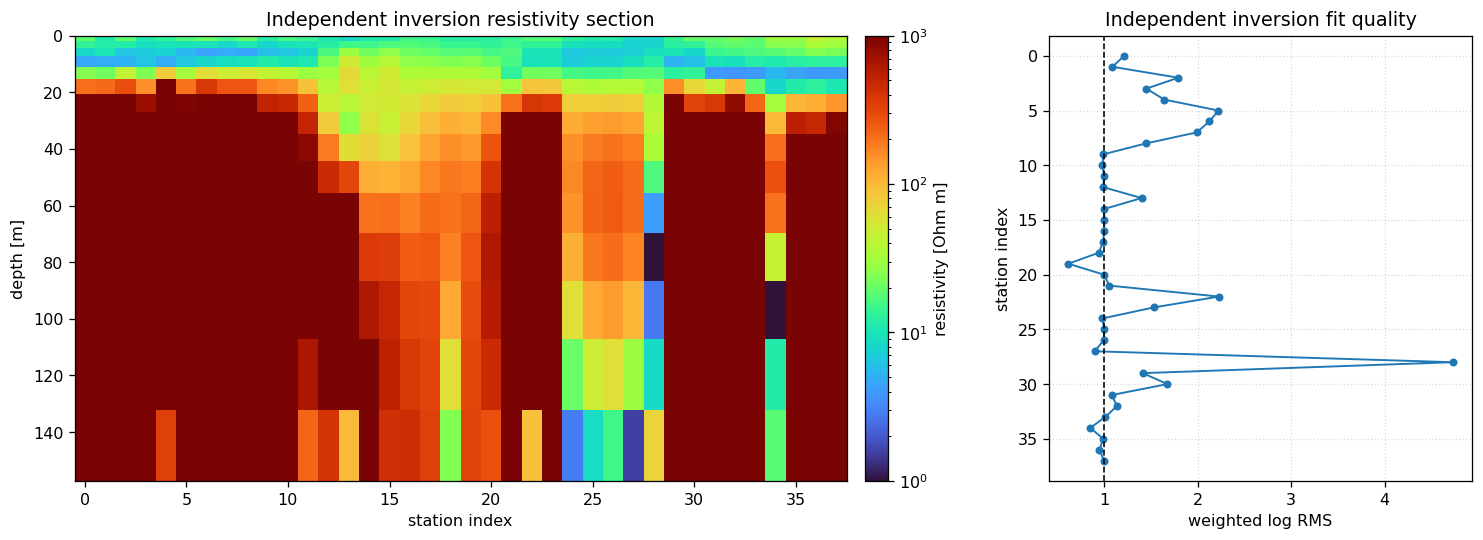

Plotted 38 stations with valid independent inversion results.
RMS range: 0.613 to 4.729


In [18]:
# Plot results from the independent (beta=0) inversion.
# Uses rho_sections/rms_stations produced in the batch inversion cell.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

if 'rho_sections' not in globals() or 'rms_stations' not in globals():
    raise RuntimeError('Run the batch inversion cell first to create rho_sections and rms_stations.')

rho_plot = np.asarray(rho_sections, dtype=float)
rms_plot = np.asarray(rms_stations, dtype=float)

valid_model = np.all(np.isfinite(rho_plot), axis=1)
valid_rms = np.isfinite(rms_plot)
valid = valid_model & valid_rms

if not np.any(valid):
    raise RuntimeError('No valid independent inversion results found to plot.')

station_idx = np.flatnonzero(valid)
rho_valid = rho_plot[valid]
rms_valid = rms_plot[valid]

# Build pcolormesh edges for stations and depth.
if station_idx.size == 1:
    x_edges = np.array([station_idx[0] - 0.5, station_idx[0] + 0.5], dtype=float)
else:
    x_edges = np.concatenate([
        [station_idx[0] - 0.5 * (station_idx[1] - station_idx[0])],
        0.5 * (station_idx[:-1] + station_idx[1:]),
        [station_idx[-1] + 0.5 * (station_idx[-1] - station_idx[-2])],
    ])
z_edges = np.concatenate([[0.0], np.cumsum(thicknesses), [np.cumsum(thicknesses)[-1] + thicknesses[-1]]])

vmin = 10.0 ** np.floor(np.log10(np.nanpercentile(rho_valid, 2)))
vmax = 10.0 ** np.ceil(np.log10(np.nanpercentile(rho_valid, 98)))
vmax = 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={'width_ratios': [2.2, 1.0]})

mesh = axes[0].pcolormesh(x_edges, z_edges, rho_valid.T, shading='flat',
                          cmap=plt.cm.turbo, norm=LogNorm(vmin=vmin, vmax=vmax))
axes[0].invert_yaxis()
axes[0].set_xlabel('station index')
axes[0].set_ylabel('depth [m]')
axes[0].set_title('Independent inversion resistivity section')

cbar = fig.colorbar(mesh, ax=axes[0], pad=0.02)
cbar.set_label('resistivity [Ohm m]')

axes[1].plot(rms_valid, station_idx, 'o-', ms=4, lw=1.2)
axes[1].axvline(1.0, color='k', ls='--', lw=1)
axes[1].invert_yaxis()
axes[1].set_xlabel('weighted log RMS')
axes[1].set_ylabel('station index')
axes[1].set_title('Independent inversion fit quality')
axes[1].grid(True, ls=':', alpha=0.45)

plt.tight_layout()
plt.show()

print(f'Plotted {station_idx.size} stations with valid independent inversion results.')
print(f'RMS range: {np.nanmin(rms_valid):.3f} to {np.nanmax(rms_valid):.3f}')

## 11. Depth of investigation (DOI)

This implements the global DOI measure of Christiansen & Auken (2012). It uses the actual system response, the recovered model, the data noise, and the number of gates, rather than a skin-depth or half-space approximation.

For each station's final model we recompute the log-log Jacobian $G_{ij} = \partial \ln d_i / \partial \ln \rho_j$ and form the error-normalized layer sensitivity

$$s_j = \sum_{i=1}^{N} \frac{|G_{ij}|}{\Delta d_i},$$

where $\Delta d_i$ is the log-space data standard deviation (the per-gate relative noise). Because the inversion weights are $w_i = d_i / \sigma_i = 1/\Delta d_i$, this is just the sum of the absolute weighted log-Jacobian columns. Cumulating from the bottom upward,

$$S_j = \sum_{k \ge j} s_k,$$

gives a dimensionless total sensitivity from each depth downward. The DOI is the depth where $S$ crosses the global threshold (default $0.8$; the paper fine-tunes in the range 0.6-1.2). Only the data part of the Jacobian is used, so the DOI reflects what the measurements themselves resolve, not the regularization.

The result is stored in `doi_stations` (per station) with `doi_sensitivity` / `doi_cumulative` holding the underlying profiles, and plotted as a black DOI line over each line's resistivity section with the region below the DOI greyed out. Set `DOI_THRESHOLD` to tune it. Note this recomputes one Jacobian per station, so it takes a little time (run in parallel across stations).


Computing DOI for 38 stations (threshold=0.8, workers=8); this recomputes one Jacobian per station.
DOI computed in 80.2 s. Range 23.5 to 132.3 m, median 77.3 m.


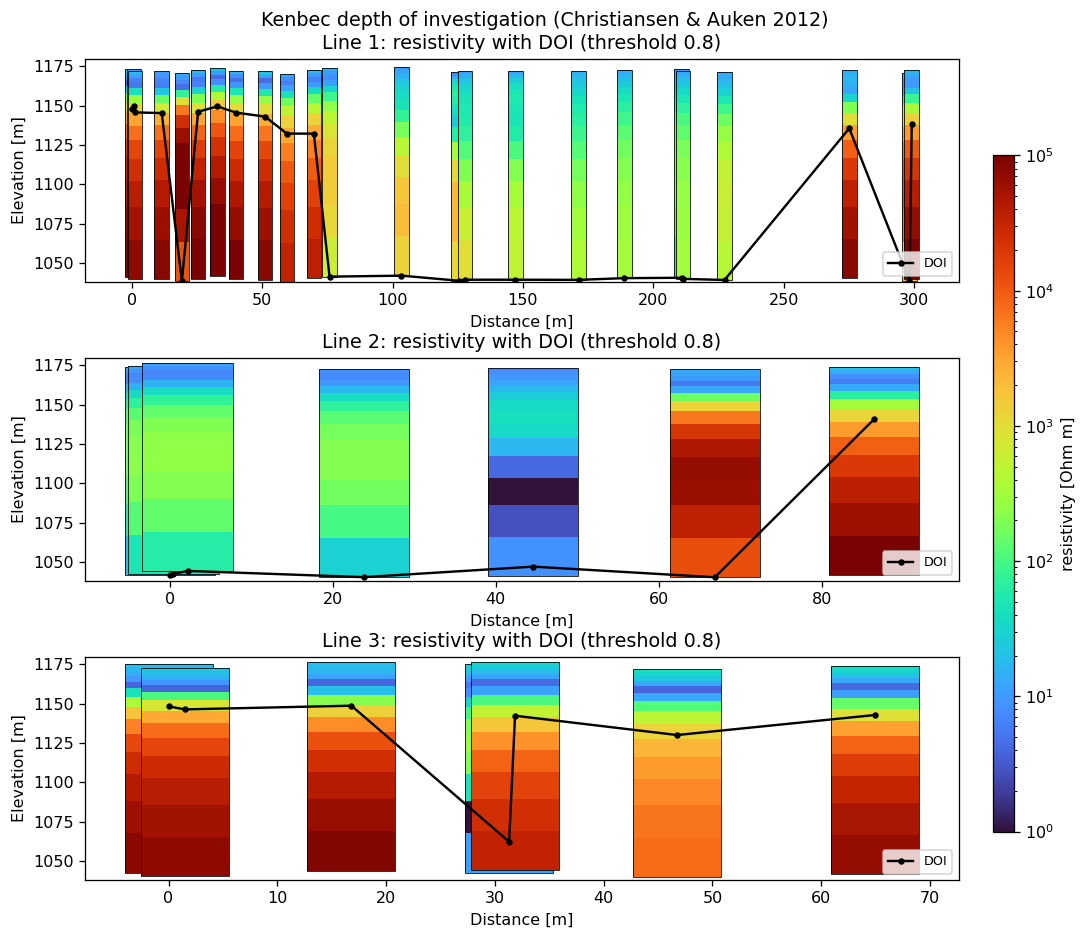

In [19]:
# =====================================================================
# Depth of investigation (DOI), Christiansen & Auken (2012).
#
# For each station's final 1D model we recompute the log-log Jacobian
#   G_ij = d ln(d_i) / d ln(rho_j),
# form the error-normalized sensitivity of each layer
#   s_j = sum_i |G_ij| / Delta_d_i     (Delta_d_i = log-space data std),
# accumulate it from the bottom upward
#   S_j = sum_{k >= j} s_k              (dimensionless),
# and define the DOI as the depth where S drops through a global threshold.
# Here Delta_d_i is the per-gate relative noise, so |G_ij| / Delta_d_i is
# exactly the weighted log-Jacobian the inversion already uses.
# =====================================================================
import time
import importlib
import sys
import utm

DOI_THRESHOLD = 0.8                                            # global threshold (paper uses 0.8)
DOI_MODEL = globals().get('rho_sections_final', rho_sections)  # models to interpret

_doi_layer_bottoms = np.cumsum(thicknesses)
_doi_model_bottom = float(_doi_layer_bottoms[-1])
_doi_layer_tops = depths_top[:rho_start.size]                  # top depth of each layer


def _weighted_log_jacobian(log_rho, station):
    """Per-gate weighted log-log Jacobian  W . dln(pred)/dln(rho)  for one station."""
    fit = station_fit_systems(station)
    obs = np.concatenate([f['obs'] for f in fit])
    noise = np.concatenate([f['noise_abs'] for f in fit])
    weights = obs / noise
    step = fwd_step_inv(thicknesses, np.exp(log_rho), shared_t_step)
    pred = np.concatenate([f['M'] @ step for f in fit])
    jac_abs = getJ_ana(
        thicknesses=thicknesses, log_resistivities=log_rho, tx_size=tx_size_inv,
        times=shared_t_step, geometry=geometry_inv, rx_x=rx_x, rx_y=rx_y,
        n_quad=N_QUAD_SQUARE, use_numba=JAC_USE_NUMBA, use_cuda=JAC_USE_CUDA,
        transform='dlf', jacobian_mode='absolute')
    gate_jac = np.vstack([f['M'] @ jac_abs for f in fit])
    log_jac = np.zeros_like(gate_jac)
    positive = pred > 0
    log_jac[positive] = gate_jac[positive] / pred[positive, None]
    return log_jac * weights[:, None]


def compute_doi(log_rho, station, threshold=DOI_THRESHOLD):
    """Return (doi_depth_m, per_layer_sensitivity, cumulative_sensitivity)."""
    weighted_jac = _weighted_log_jacobian(log_rho, station)
    sensitivity = np.abs(weighted_jac).sum(axis=0)             # eq 3, per layer
    cumulative = np.cumsum(sensitivity[::-1])[::-1]            # eq 5, from bottom up
    tops = _doi_layer_tops
    if cumulative[0] <= threshold:
        doi = 0.0
    elif cumulative[-1] >= threshold:
        doi = _doi_model_bottom
    else:
        doi = float(np.interp(threshold, cumulative[::-1], tops[::-1]))
    return doi, sensitivity, cumulative


_doi_targets = [s for s in station_ids if np.all(np.isfinite(DOI_MODEL[s]))]
doi_stations = np.full(int(tem.data.shape[0]), np.nan)
doi_sensitivity = {}
doi_cumulative = {}


def _doi_one(station):
    if _numba is not None and len(_doi_targets) > 1:
        try:
            _numba.set_num_threads(1)
        except Exception:
            pass
    doi, sens, cum = compute_doi(np.log(DOI_MODEL[station]), station)
    return station, doi, sens, cum


_doi_workers = max(1, min(int(N_WORKERS), len(_doi_targets)))
print(f'Computing DOI for {len(_doi_targets)} stations '
      f'(threshold={DOI_THRESHOLD}, workers={_doi_workers}); this recomputes one '
      f'Jacobian per station.')
_t_doi = time.perf_counter()
if _doi_workers == 1:
    _doi_results = [_doi_one(s) for s in _doi_targets]
else:
    with _cf.ThreadPoolExecutor(max_workers=_doi_workers) as executor:
        _doi_results = list(executor.map(_doi_one, _doi_targets))
for station, doi, sens, cum in _doi_results:
    doi_stations[station] = doi
    doi_sensitivity[station] = sens
    doi_cumulative[station] = cum
print(f'DOI computed in {time.perf_counter() - _t_doi:.1f} s. '
      f'Range {np.nanmin(doi_stations):.1f} to {np.nanmax(doi_stations):.1f} m, '
      f'median {np.nanmedian(doi_stations):.1f} m.')

# --- Sections via the profiler package, with the DOI line overlaid. ---
PROFILER_MODULE_DIR = (
    r"C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter"
    r"\Projects\Python\profiler\src\profiler")
if PROFILER_MODULE_DIR not in sys.path:
    sys.path.insert(0, PROFILER_MODULE_DIR)
if 'profiler' in sys.modules and not hasattr(sys.modules['profiler'], 'Model'):
    del sys.modules['profiler']
import profiler as profiler
importlib.reload(profiler)
from matplotlib.colors import LogNorm

_station_table = tem.data
_latitude = _station_table['Latitude'].to_numpy(dtype=float)
_longitude = _station_table['Longitude'].to_numpy(dtype=float)
_elevation = _station_table['Elevation'].to_numpy(dtype=float)
_line_number = _station_table['Line'].to_numpy(dtype=int)
_utm_rows = [utm.from_latlon(a, b) for a, b in zip(_latitude, _longitude)]
_easting = np.asarray([r[0] for r in _utm_rows])
_northing = np.asarray([r[1] for r in _utm_rows])
_zone_number, _zone_letter = _utm_rows[0][2], _utm_rows[0][3]
_epsg = f"epsg:{32600 + _zone_number if _zone_letter >= 'N' else 32700 + _zone_number}"

_layer_bottoms = np.cumsum(thicknesses)
_model_bottom = float(_layer_bottoms[-1])
_valid = (np.isfinite(_easting) & np.isfinite(_northing) & np.isfinite(_elevation)
          & np.all(np.isfinite(DOI_MODEL), axis=1) & np.isfinite(doi_stations))

_doi_pm = profiler.Model()
_doi_profile_lines = []
for _line in np.unique(_line_number):
    _sel = _valid & (_line_number == _line)
    if np.count_nonzero(_sel) < 2:
        continue
    _x = _easting[_sel]
    _y = _northing[_sel]
    _distance = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(_x), np.diff(_y)))])
    _spacing = np.diff(_distance)
    _spacing = _spacing[_spacing > 0]
    _width = 0.55 * np.median(_spacing) if _spacing.size else 1.0
    _rho_line = DOI_MODEL[_sel]
    _doi_pm.stem_models.append({
        'mod_name': f'Kenbec line {_line}', 'instrument': 'Kenbec sTEM', 'epsg': _epsg,
        'x': _x, 'y': _y, 'elev': _elevation[_sel], 'rhos': _rho_line,
        'depths': np.repeat(_layer_bottoms[None, :], _rho_line.shape[0], axis=0),
        'doi_con': np.full(_rho_line.shape[0], _model_bottom),
        'doi_standard': np.full(_rho_line.shape[0], _model_bottom),
        'residual': np.zeros(_rho_line.shape[0]),
        'line_num': np.full(_rho_line.shape[0], _line, dtype=int)})
    _doi_pm.profiles.append({'x': _x.copy(), 'y': _y.copy(),
        'xi': _x.copy(), 'yi': _y.copy(), 'distances': _distance})
    _doi_profile_lines.append({'line': int(_line),
        'profile_idx': len(_doi_pm.profiles) - 1,
        'model_idx': len(_doi_pm.stem_models) - 1,
        'distance': _distance, 'elev': _elevation[_sel],
        'doi': doi_stations[_sel], 'model_width': float(_width)})

if _doi_profile_lines:
    _lim = np.nanpercentile(np.log10(DOI_MODEL[_valid]), [2, 98])
    _vmin = 10.0 ** np.floor(_lim[0])
    _vmax = 10.0 ** np.ceil(_lim[1])
    _zmin = float(np.nanmin(_elevation[_valid]) - _model_bottom)
    _zmax = float(np.nanmax(_elevation[_valid]) + 3.0)
    _doi_plot = profiler.Plot(_doi_pm)
    fig, axes = plt.subplots(len(_doi_profile_lines), 1,
                             figsize=(10, 2.8 * len(_doi_profile_lines)),
                             sharey=True, squeeze=False)
    for ax, info in zip(axes[:, 0], _doi_profile_lines):
        _doi_plot.addTEMSoundings(
            profile_idx=info['profile_idx'], stem_model_idx=info['model_idx'],
            ax=ax, cmap=plt.cm.turbo, vmin=_vmin, vmax=_vmax,
            search_radius=np.inf, model_width=info['model_width'],
            boundary=True, print_msg=False)
        ax.plot(info['distance'], info['elev'] - info['doi'], 'k-o', ms=3, lw=1.5,
                label='DOI')
        ax.set_ylim(_zmin, _zmax)
        ax.set_xlabel('Distance [m]')
        ax.set_ylabel('Elevation [m]')
        ax.set_title(f"Line {info['line']}: resistivity with DOI (threshold {DOI_THRESHOLD})")
        ax.legend(loc='lower right', fontsize=8)
    _sm = plt.cm.ScalarMappable(norm=LogNorm(vmin=_vmin, vmax=_vmax), cmap=plt.cm.turbo)
    _sm.set_array([])
    fig.suptitle('Kenbec depth of investigation (Christiansen & Auken 2012)', y=0.999)
    fig.subplots_adjust(left=0.10, right=0.86, top=0.95, bottom=0.10, hspace=0.34)
    _cax = fig.add_axes([0.89, 0.15, 0.018, 0.7])
    fig.colorbar(_sm, cax=_cax, label='resistivity [Ohm m]')
    plt.show()
else:
    print('No line has >= 2 valid soundings for a DOI section plot.')


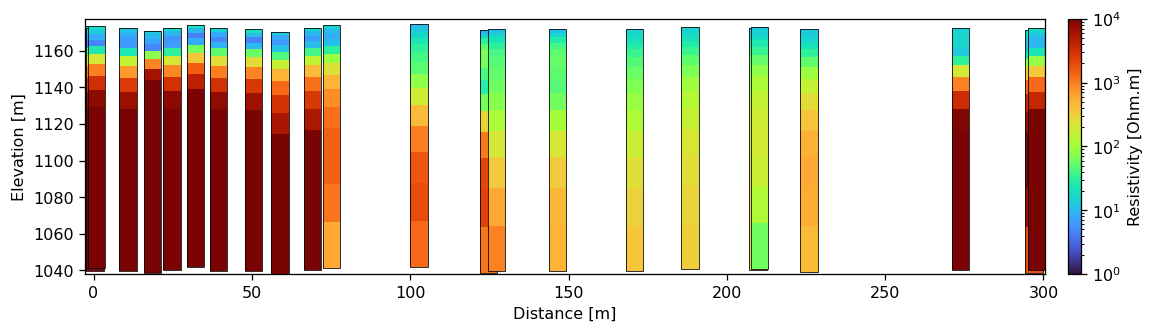

Plotted all 24 soundings on line 1; no DOI was calculated.


In [20]:
# Plot all soundings on line 1 from the existing batch inversion results.

import importlib

import sys



import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm

import numpy as np

import utm



TARGET_LINE = 1

TRANSECT_MODELS = globals().get('rho_sections_final', rho_sections)



PROFILER_MODULE_DIR = (

    r"C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter"

    r"\Projects\Python\profiler\src\profiler")

if PROFILER_MODULE_DIR not in sys.path:

    sys.path.insert(0, PROFILER_MODULE_DIR)

if 'profiler' in sys.modules and not hasattr(sys.modules['profiler'], 'Model'):

    del sys.modules['profiler']

import profiler as profiler

importlib.reload(profiler)



station_table = tem.data

latitude = station_table['Latitude'].to_numpy(dtype=float)

longitude = station_table['Longitude'].to_numpy(dtype=float)

elevation = station_table['Elevation'].to_numpy(dtype=float)

line_number = station_table['Line'].to_numpy(dtype=int)



utm_rows = [utm.from_latlon(lat, lon) for lat, lon in zip(latitude, longitude)]

easting = np.asarray([row[0] for row in utm_rows])

northing = np.asarray([row[1] for row in utm_rows])

zone_number, zone_letter = utm_rows[0][2], utm_rows[0][3]

epsg = f"epsg:{32600 + zone_number if zone_letter >= 'N' else 32700 + zone_number}"



valid = (np.isfinite(easting) & np.isfinite(northing) & np.isfinite(elevation)

         & np.all(np.isfinite(TRANSECT_MODELS), axis=1))

selection = np.flatnonzero(valid & (line_number == TARGET_LINE))

if selection.size < 2:

    raise RuntimeError(

        f'Line {TARGET_LINE} has {selection.size} valid sounding(s); at least 2 are required.')



# Keep all line soundings in spatial order along the dominant coordinate.

coordinate = (easting[selection] if np.ptp(easting[selection]) >= np.ptp(northing[selection])

              else northing[selection])

selection = selection[np.argsort(coordinate)]

x = easting[selection]

y = northing[selection]

line_elevation = elevation[selection]

rho_line = np.asarray(TRANSECT_MODELS[selection], dtype=float)

distance = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(x), np.diff(y)))])



spacing = np.diff(distance)

spacing = spacing[spacing > 0]

model_width = 0.55 * np.median(spacing) if spacing.size else 1.0

layer_bottoms = np.cumsum(thicknesses)

model_bottom = float(layer_bottoms[-1])



profile_model = profiler.Model()

profile_model.stem_models.append({

    'mod_name': f'Kenbec line {TARGET_LINE}',

    'instrument': 'Kenbec sTEM',

    'epsg': epsg,

    'x': x,

    'y': y,

    'elev': line_elevation,

    'rhos': rho_line,

    'depths': np.repeat(layer_bottoms[None, :], rho_line.shape[0], axis=0),

    'doi_con': np.full(rho_line.shape[0], model_bottom),

    'doi_standard': np.full(rho_line.shape[0], model_bottom),

    'residual': np.zeros(rho_line.shape[0]),

    'line_num': np.full(rho_line.shape[0], TARGET_LINE, dtype=int),

})

profile_model.profiles.append({

    'x': x.copy(),

    'y': y.copy(),

    'xi': x.copy(),

    'yi': y.copy(),

    'distances': distance,

})



log_limits = np.nanpercentile(np.log10(rho_line), [2, 98])

vmin = 10.0 ** np.floor(log_limits[0])

vmax = 1e4

zmin = float(np.nanmin(line_elevation) - model_bottom)

zmax = float(np.nanmax(line_elevation) + 3.0)



profile_plot = profiler.Plot(profile_model)

fig, ax = plt.subplots(figsize=(11, 3))

patches_before = len(ax.patches)

profile_plot.addTEMSoundings(

    profile_idx=0, stem_model_idx=0, ax=ax,

    cmap=plt.cm.turbo, vmin=vmin, vmax=vmax,

    search_radius=np.inf, model_width=float(model_width),

    boundary=True, print_msg=False)



# addTEMSoundings adds patches but does not autoscale the x-axis.

ax.set_xlim(distance[0] - model_width / 2, distance[-1] + model_width / 2)

ax.set_ylim(zmin, zmax)

ax.set_xlabel('Distance [m]')

ax.set_ylabel('Elevation [m]')





scalar_mappable = plt.cm.ScalarMappable(

    norm=LogNorm(vmin=vmin, vmax=vmax), cmap=plt.cm.turbo)

scalar_mappable.set_array([])

fig.colorbar(scalar_mappable, ax=ax, pad=0.02, label='Resistivity [Ohm.m]')

fig.tight_layout()

plt.show()



patches_added = len(ax.patches) - patches_before

expected_patches = selection.size * rho_line.shape[1]

if patches_added != expected_patches:

    raise RuntimeError(

        f'Expected {expected_patches} sounding patches, but profiler added {patches_added}.')

print(f'Plotted all {selection.size} soundings on line {TARGET_LINE}; no DOI was calculated.')


In [21]:
# Diagnose extreme recovered resistivities on the plotted transect.

line_rms = np.asarray(rms_stations, dtype=float)[selection]

layer_tops = np.asarray(depths_top[:rho_line.shape[1]], dtype=float)

layer_max = np.nanmax(rho_line, axis=0)

extreme_rows, extreme_layers = np.where(rho_line >= 1.0e4)



print(f'Line {TARGET_LINE} resistivity range: '

      f'{np.nanmin(rho_line):.2f} to {np.nanmax(rho_line):.2f} Ohm m')

print(f'Values >= 10,000 Ohm m: {extreme_rows.size}')

print(f'Values at upper inversion bound ({RHO_MAX:g} Ohm m): '

      f'{np.count_nonzero(np.isclose(rho_line, RHO_MAX))}')

print('\nMaximum recovered resistivity by layer:')

for layer, (top, maximum) in enumerate(zip(layer_tops, layer_max)):

    print(f'  layer {layer:02d}, top {top:6.1f} m: {maximum:10.1f} Ohm m')



if extreme_rows.size:

    print('\nModels containing values >= 10,000 Ohm m:')

    for row in np.unique(extreme_rows):

        station = int(selection[row])

        layers = extreme_layers[extreme_rows == row]

        values = rho_line[row, layers]

        details = ', '.join(

            f'layer {layer} (top {layer_tops[layer]:.1f} m)={value:.0f}'

            for layer, value in zip(layers, values))

        print(f'  station {station:02d}, RMS={line_rms[row]:.3f}: {details}')


Line 1 resistivity range: 4.30 to 100000.00 Ohm m
Values >= 10,000 Ohm m: 79
Values at upper inversion bound (100000 Ohm m): 15

Maximum recovered resistivity by layer:
  layer 00, top    0.0 m:       20.5 Ohm m
  layer 01, top    2.0 m:       17.1 Ohm m
  layer 02, top    4.4 m:       29.7 Ohm m
  layer 03, top    7.4 m:       51.3 Ohm m
  layer 04, top   11.0 m:       77.4 Ohm m
  layer 05, top   15.3 m:      978.9 Ohm m
  layer 06, top   20.6 m:     6426.0 Ohm m
  layer 07, top   27.0 m:    25060.6 Ohm m
  layer 08, top   34.8 m:    64067.9 Ohm m
  layer 09, top   44.3 m:   100000.0 Ohm m
  layer 10, top   55.8 m:   100000.0 Ohm m
  layer 11, top   69.7 m:   100000.0 Ohm m
  layer 12, top   86.7 m:   100000.0 Ohm m
  layer 13, top  107.3 m:   100000.0 Ohm m
  layer 14, top  132.3 m:   100000.0 Ohm m

Models containing values >= 10,000 Ohm m:
  station 01, RMS=1.085: layer 9 (top 44.3 m)=19025, layer 10 (top 55.8 m)=32817, layer 11 (top 69.7 m)=50387, layer 12 (top 86.7 m)=70543, lay

## 12. Depth of investigation, Oldenburg & Li (1999)

An independent, complementary DOI estimate that probes the influence of the regularization directly, rather than the Jacobian sensitivity. Each sounding is inverted twice with the **same data** but two contrasting reference (and starting) half-spaces, using Tikhonov regularization that pulls the model toward its reference:

$$\min_m \; \lVert W\,(d - F(m)) \rVert_2^2 \; + \; \beta\,\lVert m - m_\text{ref} \rVert_2^2 .$$

Where the data constrain the model, both inversions converge to the same result; where they do not, each model relaxes back to its own reference. The normalized model difference

$$R_j = \frac{m^{(1)}_j - m^{(2)}_j}{m^{(1)}_\text{ref} - m^{(2)}_\text{ref}} \quad (\text{log-resistivity})$$

is close to 0 where the model is data-driven and approaches 1 where it is reference-driven. The DOI is the depth where $|R|$ first crosses `OL_THRESHOLD` (0.5 by default).

Controls: `OL_RHO_REF_LOW` / `OL_RHO_REF_HIGH` (the two reference half-spaces, e.g. 5 and 500 Ohm m), `OL_BETA` (the regularization weight; stronger beta gives a shallower DOI, so keep it fixed and equal for both runs), and `OL_THRESHOLD`. Results are stored in `doi_ol_stations`, with `ol_index`, `ol_model_low`, and `ol_model_high` holding the underlying profiles, and plotted as the $|R|$ section per line with the DOI line overlaid.

As the paper notes, this requires the full inversion to be carried out at least twice, so it costs roughly 2x the independent inversion. Unlike the Christiansen & Auken measure (section 11), the resulting DOI does depend on the regularization strength, which is exactly what it is designed to expose.


Oldenburg-Li DOI: two reference inversions per station for 38 stations (workers=8). Cost is ~2x the independent inversion.
Oldenburg-Li DOI computed in 5799.2 s. Range 0.0 to 132.3 m, median 0.6 m.


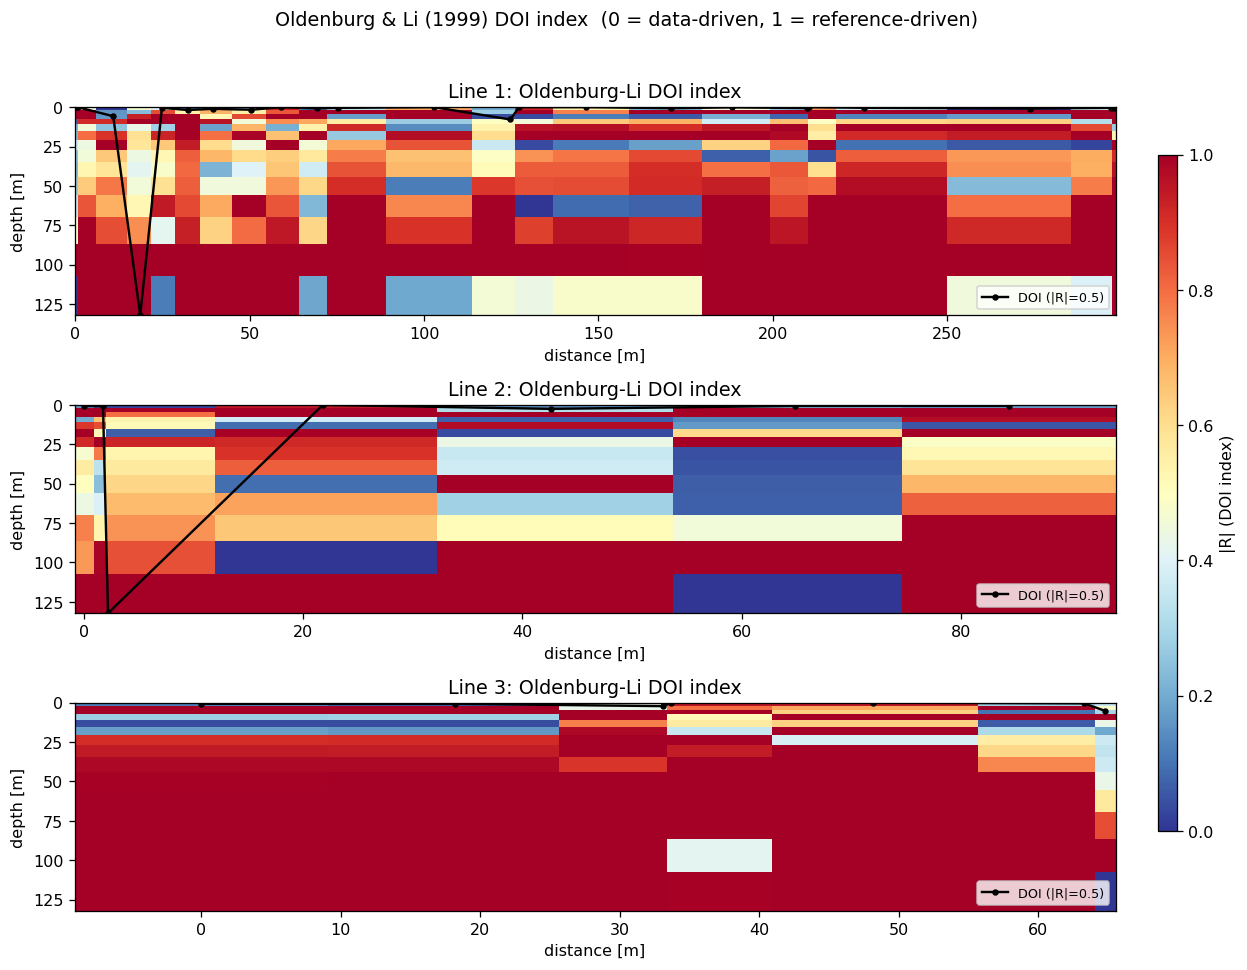

In [22]:
# =====================================================================
# Depth of investigation, Oldenburg & Li (1999) reference-model method.
#
# Invert each sounding TWICE with the same data but two very different
# reference (and starting) half-spaces, using Tikhonov regularization that
# pulls the model toward its reference:
#     min_m  ||W (d - F(m))||^2  +  beta ||m - m_ref||^2 .
# Where the data constrain the model both inversions agree; where they do
# not, each model follows its own reference. The normalized difference
#     R_j = (m1_j - m2_j) / (m_ref1 - m_ref2)      (log-resistivity)
# is ~0 where data-driven and ->1 where reference-driven. The DOI is the
# depth where |R| first exceeds a threshold.
# =====================================================================
import time
import utm
from pytem import getJ_ana as _getJ_ana_raw

OL_RHO_REF_LOW = 5.0        # Ohm-m, reference half-space 1
OL_RHO_REF_HIGH = 500.0     # Ohm-m, reference half-space 2
OL_BETA = 0.3               # reference-model regularization weight (tune)
OL_MAXIT = 15
OL_MAX_BACKTRACK = 8
OL_THRESHOLD = 0.5          # DOI index threshold on |R|

OL_MODEL_BOTTOM = float(np.cumsum(thicknesses)[-1])
OL_LAYER_TOPS = depths_top[:rho_start.size]
_ol_log_low = np.full(rho_start.size, np.log(OL_RHO_REF_LOW))
_ol_log_high = np.full(rho_start.size, np.log(OL_RHO_REF_HIGH))
_ol_denominator = _ol_log_low - _ol_log_high      # constant (log-resistivity gap)


def _ol_invert_reference(station, log_ref, beta=OL_BETA, maxit=OL_MAXIT):
    """Tikhonov inversion of one sounding, pulling the model toward a reference."""
    fit = station_fit_systems(station)
    obs = np.concatenate([f['obs'] for f in fit])
    noise = np.concatenate([f['noise_abs'] for f in fit])
    weights = obs / noise
    lower, upper = np.log(RHO_MIN), np.log(RHO_MAX)
    reference = np.clip(np.asarray(log_ref, dtype=float), lower, upper)
    model = reference.copy()
    identity = np.eye(model.size)

    def predict(m):
        step = fwd_step_inv(thicknesses, np.exp(m), shared_t_step)
        return np.concatenate([f['M'] @ step for f in fit])

    def objective(m, pred):
        resid = np.log(obs) - np.log(np.maximum(pred, 1e-300))
        data = float(np.sum((weights * resid) ** 2))
        reg = float(beta * np.sum((m - reference) ** 2))
        return data + reg, resid

    pred = predict(model)
    obj, resid = objective(model, pred)
    for _ in range(maxit):
        jac_abs = _getJ_ana_raw(
            thicknesses=thicknesses, log_resistivities=model, tx_size=tx_size_inv,
            times=shared_t_step, geometry=geometry_inv, rx_x=rx_x, rx_y=rx_y,
            n_quad=N_QUAD_SQUARE, use_numba=JAC_USE_NUMBA, use_cuda=JAC_USE_CUDA,
            transform='dlf', jacobian_mode='absolute')
        gate_jac = np.vstack([f['M'] @ jac_abs for f in fit])
        log_jac = np.zeros_like(gate_jac)
        positive = pred > 0
        log_jac[positive] = gate_jac[positive] / pred[positive, None]
        weighted_jac = log_jac * weights[:, None]
        weighted_resid = weights * resid
        lhs = weighted_jac.T @ weighted_jac + beta * identity
        rhs = weighted_jac.T @ weighted_resid - beta * (model - reference)
        update = np.linalg.solve(lhs, rhs)
        step_len = 1.0
        improved = False
        for _ in range(OL_MAX_BACKTRACK):
            trial = np.clip(model + step_len * update, lower, upper)
            trial_pred = predict(trial)
            trial_obj, trial_resid = objective(trial, trial_pred)
            if trial_obj < obj:
                model, pred, resid, obj = trial, trial_pred, trial_resid, trial_obj
                improved = True
                break
            step_len *= 0.5
        if not improved:
            break
    rms = float(np.sqrt(np.mean((weights * resid) ** 2)))
    return model, rms


_ol_targets = list(station_ids)
_n_all_stations = int(tem.data.shape[0])
doi_ol_stations = np.full(_n_all_stations, np.nan)
ol_index = {}
ol_model_low = np.full((_n_all_stations, rho_start.size), np.nan)
ol_model_high = np.full((_n_all_stations, rho_start.size), np.nan)


def _ol_one(station):
    if _numba is not None and len(_ol_targets) > 1:
        try:
            _numba.set_num_threads(1)
        except Exception:
            pass
    m_low, rms_low = _ol_invert_reference(station, _ol_log_low)
    m_high, rms_high = _ol_invert_reference(station, _ol_log_high)
    doi_index = (m_low - m_high) / _ol_denominator
    return station, m_low, m_high, doi_index


_ol_workers = max(1, min(int(N_WORKERS), len(_ol_targets)))
print(f'Oldenburg-Li DOI: two reference inversions per station for '
      f'{len(_ol_targets)} stations (workers={_ol_workers}). '
      f'Cost is ~2x the independent inversion.')
_t_ol = time.perf_counter()
if _ol_workers == 1:
    _ol_results = [_ol_one(s) for s in _ol_targets]
else:
    with _cf.ThreadPoolExecutor(max_workers=_ol_workers) as executor:
        _ol_results = list(executor.map(_ol_one, _ol_targets))

for station, m_low, m_high, doi_index in _ol_results:
    ol_model_low[station] = np.exp(m_low)
    ol_model_high[station] = np.exp(m_high)
    ol_index[station] = doi_index
    abs_index = np.abs(doi_index)
    tops = OL_LAYER_TOPS
    if abs_index[0] >= OL_THRESHOLD:
        doi = 0.0
    elif abs_index[-1] <= OL_THRESHOLD:
        doi = OL_MODEL_BOTTOM
    else:
        idx = int(np.argmax(abs_index >= OL_THRESHOLD))
        if idx == 0:
            doi = 0.0
        else:
            x0, x1 = abs_index[idx - 1], abs_index[idx]
            z0, z1 = tops[idx - 1], tops[idx]
            doi = float(z0 + (OL_THRESHOLD - x0) * (z1 - z0) / (x1 - x0)) if x1 != x0 else z1
    doi_ol_stations[station] = doi
print(f'Oldenburg-Li DOI computed in {time.perf_counter() - _t_ol:.1f} s. '
      f'Range {np.nanmin(doi_ol_stations):.1f} to {np.nanmax(doi_ol_stations):.1f} m, '
      f'median {np.nanmedian(doi_ol_stations):.1f} m.')

# --- Plot the DOI index |R| per line with the DOI line. ---
_ol_line_no = tem.data['Line'].to_numpy(dtype=int)
_ol_lat = tem.data['Latitude'].to_numpy(dtype=float)
_ol_lon = tem.data['Longitude'].to_numpy(dtype=float)
_ol_utm = [utm.from_latlon(a, b) for a, b in zip(_ol_lat, _ol_lon)]
_ol_east = np.asarray([r[0] for r in _ol_utm])
_ol_north = np.asarray([r[1] for r in _ol_utm])
_ol_valid = np.isfinite(doi_ol_stations) & np.isfinite(_ol_east) & np.isfinite(_ol_north)
# One depth edge per layer boundary plus a bottom edge for the half-space
# (n_layers + 1 edges so pcolormesh matches the n_layers rows of |R|).
_ol_depth_edges = np.concatenate([[0.0], np.cumsum(thicknesses),
                                  [float(np.sum(thicknesses)) + float(thicknesses[-1])]])
_ol_lines = [ln for ln in np.unique(_ol_line_no)
             if np.count_nonzero(_ol_valid & (_ol_line_no == ln)) >= 2]
if _ol_lines:
    fig, axes = plt.subplots(len(_ol_lines), 1,
                             figsize=(11, 2.8 * len(_ol_lines)), squeeze=False)
    mesh = None
    for ax, ln in zip(axes[:, 0], _ol_lines):
        sel = np.flatnonzero(_ol_valid & (_ol_line_no == ln))
        order = np.argsort(_ol_east[sel] if np.ptp(_ol_east[sel]) >= np.ptp(_ol_north[sel])
                           else _ol_north[sel])
        sel = sel[order]
        xs, ys = _ol_east[sel], _ol_north[sel]
        dist = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(xs), np.diff(ys)))])
        dist_edges = np.concatenate([
            [dist[0] - 0.5 * (dist[1] - dist[0])],
            0.5 * (dist[:-1] + dist[1:]),
            [dist[-1] + 0.5 * (dist[-1] - dist[-2])]])
        index_section = np.abs(np.vstack([ol_index[s] for s in sel]))
        mesh = ax.pcolormesh(dist_edges, _ol_depth_edges, index_section.T,
                             cmap=plt.cm.RdYlBu_r, vmin=0.0, vmax=1.0, shading='flat')
        ax.plot(dist, doi_ol_stations[sel], 'k-o', ms=3, lw=1.5,
                label=f'DOI (|R|={OL_THRESHOLD})')
        ax.set_ylim(OL_MODEL_BOTTOM, 0.0)
        ax.set_xlim(dist_edges[0], dist_edges[-1])
        ax.set_xlabel('distance [m]')
        ax.set_ylabel('depth [m]')
        ax.set_title(f'Line {ln}: Oldenburg-Li DOI index')
        ax.legend(loc='lower right', fontsize=8)
    fig.suptitle('Oldenburg & Li (1999) DOI index  (0 = data-driven, 1 = reference-driven)',
                 y=0.999)
    fig.tight_layout(rect=(0, 0, 0.9, 0.98))
    cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label('|R| (DOI index)')
    plt.show()
else:
    print('No line has >= 2 valid soundings for an Oldenburg-Li DOI plot.')
